# Anime Content-Based Recommendation System

## Project Objective

The objective of this project is to build an Anime Content-Based Recommendation System using the provided anime and rating datasets.

This project follows the assignment requirements:

1. Load the datasets into the Python environment.
2. Perform Exploratory Data Analysis (EDA) and visualizations.
3. Check distributions and skewness in the variables and apply transformations only if required.
4. Create a content-based recommender system.

## Recommendation System Scope

This project focuses on a content-based recommendation approach. The recommendation logic will use anime-level content features such as genre, type, and episode-related information.

The rating dataset will be analyzed and aggregated to support EDA, popularity analysis, and app display. It will not be used to build collaborative filtering because the assignment specifically asks for a content-based recommender system.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 1: Load Raw Datasets

In this step, we load the two raw datasets provided for the assignment:
- `anime.csv`: contains anime-level information such as name, genre, type, episodes, rating, and members.
- `rating.csv`: contains user-anime rating interactions.

Both datasets will be loaded separately first. We will not clean, merge, or modify the data in this step.

In [2]:
anime_df = pd.read_csv("anime.csv")
rating_df = pd.read_csv("rating.csv")

print("Datasets loaded successfully.")
print("Anime dataset shape:", anime_df.shape)
print("Rating dataset shape:", rating_df.shape)

Datasets loaded successfully.
Anime dataset shape: (12294, 7)
Rating dataset shape: (7813737, 3)


# Step 2: Initial dataset inspection

In this step, we inspect the structure of both datasets.
- First few rows
- Column names
- Data types
- Basic dataframe information

In [3]:
print("Anime dataset preview:")
display(anime_df.head())

print("Rating dataset preview:")
display(rating_df.head())

Anime dataset preview:


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


Rating dataset preview:


,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


In [4]:
# Check columns and data types
print("Anime dataset columns:")
print(anime_df.columns.tolist())

print("\nRating dataset columns:")
print(rating_df.columns.tolist())

print("\nAnime dataset information:")
anime_df.info()

print("\nRating dataset information:")
rating_df.info()

Anime dataset columns:
['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']

Rating dataset columns:
['user_id', 'anime_id', 'rating']

Anime dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB

Rating dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


## Raw data insights

- The anime dataset contains anime-level information with 12,294 rows and 7 columns.
- The main anime identifier is `anime_id`, and the anime title column is `name`.
- The available anime content fields are `genre`, `type`, and `episodes`. These are important for building a content-based recommender system.
- The anime dataset also contains `rating` and `members`, which can be used for EDA, popularity analysis, filtering, and app display.
- The rating dataset contains user-anime interaction data with 7,813,737 rows and 3 columns: `user_id`, `anime_id`, and `rating`.
- The rating dataset can support collaborative filtering, but this project will not build collaborative filtering because the assignment specifically asks for a content-based recommender system.
- The `genre`, `type`, and `rating` columns in the anime dataset have some missing values, so they need to be handled during data cleaning.
- The `episodes` column is stored as text, so it needs further inspection before using it for distribution analysis or recommendation features.
- The preview of the rating dataset shows `-1` rating values, so the rating column needs special analysis before calculating user rating summaries.

---

# Step 3: Missing value and duplicate analysis

In this step, we check missing values and duplicate rows in both datasets.
This step helps us understand data quality issues before cleaning. We will not modify the datasets yet.

In [5]:

def missing_value_summary(df, dataset_name):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    summary = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percentage": missing_percent.round(2)
    })
    
    summary = summary[summary["missing_count"] > 0].sort_values(
        by="missing_count", ascending=False
    )
    
    print(f"Missing value summary for {dataset_name}:")
    
    if summary.empty:
        print("No missing values found.")
    else:
        display(summary)

In [6]:
# Check missing values in both datasets
missing_value_summary(anime_df, "anime_df")
print("\n" + "-"*60 + "\n")
missing_value_summary(rating_df, "rating_df")

Missing value summary for anime_df:


,missing_count,missing_percentage
rating,230,1.87
genre,62,0.50
type,25,0.20



------------------------------------------------------------

Missing value summary for rating_df:
No missing values found.


In [6]:
# Check duplicate rows in both datasets

anime_duplicates = anime_df.duplicated().sum()
rating_duplicates = rating_df.duplicated().sum()

print("Duplicate rows in anime_df:", anime_duplicates)
print("Duplicate rows in rating_df:", rating_duplicates)

Duplicate rows in anime_df: 0
Duplicate rows in rating_df: 1


In [7]:
# Display duplicate rows in rating_df, if any

if rating_duplicates > 0:
    print("Duplicate rows found in rating_df:")
    display(rating_df[rating_df.duplicated(keep=False)].sort_values(
        by=["user_id", "anime_id", "rating"]
    ))
else:
    print("No duplicate rows found in rating_df.")

Duplicate rows found in rating_df:


,user_id,anime_id,rating
4499258,42653,16498,8
4499316,42653,16498,8


In [8]:
# Data quality summary

data_quality_summary = pd.DataFrame({
    "dataset": ["anime_df", "rating_df"],
    "rows": [anime_df.shape[0], rating_df.shape[0]],
    "columns": [anime_df.shape[1], rating_df.shape[1]],
    "missing_values_total": [anime_df.isnull().sum().sum(), rating_df.isnull().sum().sum()],
    "duplicate_rows": [anime_duplicates, rating_duplicates]
})

display(data_quality_summary)

,dataset,rows,columns,missing_values_total,duplicate_rows
0,anime_df,12294,7,317,0
1,rating_df,7813737,3,0,1


## Insights

- The anime dataset has 317 missing values in total.
- Missing values are present in three columns: `rating` has 230 missing values, `genre` has 62 missing values, and `type` has 25 missing values.
- The `rating_df` dataset has no missing values.
- The anime dataset has no duplicate rows.
- The rating dataset has 1 duplicate row.
- The duplicate row in `rating_df` represents the same `user_id`, `anime_id`, and `rating` combination repeated twice.
- Since `rating_df` will be aggregated later, the duplicate row should be removed before aggregation to avoid slightly overstating user interaction counts.
- Missing `genre` and `type` values need to be handled carefully because these columns are important for the content-based recommender system.
- Missing anime `rating` values should not be blindly filled yet. We will decide how to handle them based on how the rating column is used during EDA, filtering, and app display.

----

# Step 4: Clean rating data

In this step, we clean the `rating_df` dataset before aggregation.

The rating dataset contains user-anime rating interactions. Before using it for user rating summaries, we need to:
- Analyze the values in the `rating` column.
- Confirm how many `-1` values are present.
- Treat `rating = -1` as "not rated", not as a real rating.
- Remove duplicate rows.
- Create a valid rating dataset that excludes `-1`.

In [9]:
rating_value_summary = (
    rating_df["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating_value")
    .reset_index(name="count")
)

rating_value_summary["percentage"] = (
    rating_value_summary["count"] / len(rating_df) * 100
).round(2)

display(rating_value_summary)

total_rating_rows = len(rating_df)
unrated_count = (rating_df["rating"] == -1).sum()
valid_rating_count = (rating_df["rating"] != -1).sum()

print("Total rows in rating_df:", total_rating_rows)
print("Rows with rating = -1:", unrated_count)
print("Rows with valid ratings:", valid_rating_count)
print("Percentage of rating = -1:", round((unrated_count / total_rating_rows) * 100, 2), "%")

,rating_value,count,percentage
0,-1,1476496,18.90
1,1,16649,0.21
2,2,23150,0.30
3,3,41453,0.53
4,4,104291,1.33
5,5,282806,3.62
6,6,637775,8.16
7,7,1375287,17.60
8,8,1646019,21.07
9,9,1254096,16.05


Total rows in rating_df: 7813737
Rows with rating = -1: 1476496
Rows with valid ratings: 6337241
Percentage of rating = -1: 18.9 %


In [10]:
# Remove duplicate rows from rating_df
rating_clean = rating_df.drop_duplicates().copy()

print("Original rating_df shape:", rating_df.shape)
print("Cleaned rating_clean shape:", rating_clean.shape)
print("Duplicate rows removed:", rating_df.shape[0] - rating_clean.shape[0])

Original rating_df shape: (7813737, 3)
Cleaned rating_clean shape: (7813736, 3)
Duplicate rows removed: 1


In [11]:
# Separate valid ratings and unrated interactions
valid_rating_df = rating_clean[rating_clean["rating"] != -1].copy()
unrated_df = rating_clean[rating_clean["rating"] == -1].copy()

print("rating_clean shape:", rating_clean.shape)
print("valid_rating_df shape:", valid_rating_df.shape)
print("unrated_df shape:", unrated_df.shape)

print("\nMinimum valid rating:", valid_rating_df["rating"].min())
print("Maximum valid rating:", valid_rating_df["rating"].max())

print("\nUnique valid rating values:")
print(sorted(valid_rating_df["rating"].unique()))

rating_clean shape: (7813736, 3)
valid_rating_df shape: (6337240, 3)
unrated_df shape: (1476496, 3)

Minimum valid rating: 1
Maximum valid rating: 10

Unique valid rating values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [12]:
# Rating data cleaning summary
rating_cleaning_summary = pd.DataFrame({
    "metric": [
        "Original rating rows",
        "Duplicate rows removed",
        "Rows after duplicate removal",
        "Valid rating rows",
        "Unrated rows with rating = -1"
    ],
    "value": [
        len(rating_df),
        len(rating_df) - len(rating_clean),
        len(rating_clean),
        len(valid_rating_df),
        len(unrated_df)
    ]
})

display(rating_cleaning_summary)

,metric,value
0,Original rating rows,7813737
1,Duplicate rows removed,1
2,Rows after duplicate removal,7813736
3,Valid rating rows,6337240
4,Unrated rows with rating = -1,1476496


## Step 4 insights

- The rating dataset originally had 7,813,737 rows.
- The `rating` column contains values from `-1` to `10`.
- `rating = -1` appears 1,476,496 times, which is 18.90% of the rating dataset.
- `rating = -1` is treated as "not rated" and not as a real rating score.
- Valid user ratings are from 1 to 10.
- After removing 1 duplicate row, the cleaned rating dataset has 7,813,736 rows.
- The valid rating dataset has 6,337,240 rows after excluding `rating = -1`.
- The unrated dataset has 1,476,496 rows.
- For future aggregation, `rating_clean` will be used to count total interactions and unrated interactions.
- `valid_rating_df` will be used to calculate valid user rating count and average user rating.

---

# Step 5: Aggregate rating data

In this step, we aggregate the cleaned rating dataset at `anime_id` level. This is required because the raw rating dataset contains user-anime interaction rows. Directly merging it with the anime dataset would create millions of repeated anime rows.

We will create one summary row per anime with:
- `total_interactions`: total number of user interactions for each anime
- `valid_rating_count`: number of real ratings, excluding `rating = -1`
- `avg_user_rating`: average user rating using only valid ratings
- `unrated_count`: number of interactions where `rating = -1`

In [13]:
total_interactions_summary = (
    rating_clean
    .groupby("anime_id")
    .size()
    .reset_index(name="total_interactions")
)

valid_rating_summary = (
    valid_rating_df
    .groupby("anime_id")
    .agg(
        valid_rating_count=("rating", "count"),
        avg_user_rating=("rating", "mean")
    )
    .reset_index()
)

unrated_summary = (
    unrated_df
    .groupby("anime_id")
    .size()
    .reset_index(name="unrated_count")
)

rating_summary = total_interactions_summary.merge(
    valid_rating_summary,
    on="anime_id",
    how="left"
).merge(
    unrated_summary,
    on="anime_id",
    how="left"
)

rating_summary["valid_rating_count"] = rating_summary["valid_rating_count"].fillna(0).astype(int)
rating_summary["unrated_count"] = rating_summary["unrated_count"].fillna(0).astype(int)

rating_summary["avg_user_rating"] = rating_summary["avg_user_rating"].round(2)

rating_summary = rating_summary[
    ["anime_id", "total_interactions", "valid_rating_count", "avg_user_rating", "unrated_count"]
]

print("Rating summary created successfully.")
print("rating_summary shape:", rating_summary.shape)

display(rating_summary.head())

Rating summary created successfully.
rating_summary shape: (11200, 5)


,anime_id,total_interactions,valid_rating_count,avg_user_rating,unrated_count
0,1,15509,13449,8.87,2060
1,5,6927,5790,8.44,1137
2,6,11077,9385,8.42,1692
3,7,2629,2169,7.53,460
4,8,413,308,7.20,105


In [14]:
# Validate rating aggregation

print("Unique anime_id values in rating_clean:", rating_clean["anime_id"].nunique())
print("Rows in rating_summary:", rating_summary.shape[0])

print("\nTotal interactions check:")
print("Sum of total_interactions:", rating_summary["total_interactions"].sum())
print("Rows in rating_clean:", len(rating_clean))

print("\nValid rating count check:")
print("Sum of valid_rating_count:", rating_summary["valid_rating_count"].sum())
print("Rows in valid_rating_df:", len(valid_rating_df))

print("\nUnrated count check:")
print("Sum of unrated_count:", rating_summary["unrated_count"].sum())
print("Rows in unrated_df:", len(unrated_df))

# Check whether total interactions = valid ratings + unrated interactions for every anime
rating_summary["count_check"] = (
    rating_summary["valid_rating_count"] + rating_summary["unrated_count"]
)

mismatch_count = (
    rating_summary["total_interactions"] != rating_summary["count_check"]
).sum()

print("\nRows where total_interactions does not match valid_rating_count + unrated_count:", mismatch_count)

# Drop temporary validation column
rating_summary = rating_summary.drop(columns=["count_check"])

Unique anime_id values in rating_clean: 11200
Rows in rating_summary: 11200

Total interactions check:
Sum of total_interactions: 7813736
Rows in rating_clean: 7813736

Valid rating count check:
Sum of valid_rating_count: 6337240
Rows in valid_rating_df: 6337240

Unrated count check:
Sum of unrated_count: 1476496
Rows in unrated_df: 1476496

Rows where total_interactions does not match valid_rating_count + unrated_count: 0


In [15]:
# Check anime that have interactions but no valid user ratings
no_valid_rating_count = rating_summary["avg_user_rating"].isnull().sum()

print("Anime with interactions but no valid user ratings:", no_valid_rating_count)

display(
    rating_summary[rating_summary["avg_user_rating"].isnull()]
    .head()
)

Anime with interactions but no valid user ratings: 1273


,anime_id,total_interactions,valid_rating_count,avg_user_rating,unrated_count
1261,1396,3,0,NaN,3
1694,1863,2,0,NaN,2
1889,2075,3,0,NaN,3
2423,2642,2,0,NaN,2
2487,2708,1,0,NaN,1


## Step 5 insights

- The cleaned rating dataset was successfully aggregated at `anime_id` level.
- The `rating_summary` dataset has 11,200 rows and 5 columns, meaning 11,200 anime have user interaction records in the rating dataset.
- The total interaction count in `rating_summary` matches the row count of `rating_clean`, confirming that no interactions were lost during aggregation.
- The sum of `valid_rating_count` matches the number of rows in `valid_rating_df`, confirming that only real ratings from 1 to 10 were used for valid rating counts.
- The sum of `unrated_count` matches the number of rows in `unrated_df`, confirming that `rating = -1` interactions were counted separately.
- There are 0 mismatches between `total_interactions` and `valid_rating_count + unrated_count`, so the aggregation is internally consistent.
- There are 1,273 anime with interactions but no valid user ratings. These anime only have `rating = -1` interactions, so their `avg_user_rating` remains missing.
- This aggregated rating summary can now be safely merged with the anime dataset without creating millions of repeated user-anime rows.

---

# Step 6: Merge dataset

In this step, we safely merge the anime dataset with the aggregated rating summary.
We will use a left merge from `anime_df` to `rating_summary` using `anime_id`.
This keeps one row per anime and avoids creating millions of repeated user-anime rows.

After the merge:
- All anime rows from `anime_df` should be retained.
- Rating summary columns will be added where matching `anime_id` values exist.
- Anime with no rating interactions will have missing rating summary values, which will be handled carefully.

In [16]:
# Check anime_id uniqueness and overlap before merge
anime_id_duplicates = anime_df["anime_id"].duplicated().sum()
rating_summary_id_duplicates = rating_summary["anime_id"].duplicated().sum()

anime_ids = set(anime_df["anime_id"])
rating_summary_ids = set(rating_summary["anime_id"])

common_anime_ids = anime_ids.intersection(rating_summary_ids)
anime_only_ids = anime_ids - rating_summary_ids
rating_only_ids = rating_summary_ids - anime_ids

print("Duplicate anime_id values in anime_df:", anime_id_duplicates)
print("Duplicate anime_id values in rating_summary:", rating_summary_id_duplicates)

print("\nUnique anime_id values in anime_df:", len(anime_ids))
print("Unique anime_id values in rating_summary:", len(rating_summary_ids))
print("Common anime_id values:", len(common_anime_ids))
print("Anime IDs only in anime_df:", len(anime_only_ids))
print("Anime IDs only in rating_summary:", len(rating_only_ids))

Duplicate anime_id values in anime_df: 0
Duplicate anime_id values in rating_summary: 0

Unique anime_id values in anime_df: 12294
Unique anime_id values in rating_summary: 11200
Common anime_id values: 11197
Anime IDs only in anime_df: 1097
Anime IDs only in rating_summary: 3


In [17]:
# Safely merge anime_df with rating_summary
anime_merged = anime_df.merge(
    rating_summary,
    on="anime_id",
    how="left",
    validate="one_to_one",
    indicator=True
)

print("Original anime_df shape:", anime_df.shape)
print("rating_summary shape:", rating_summary.shape)
print("anime_merged shape:", anime_merged.shape)

print("\nMerge status counts:")
display(anime_merged["_merge"].value_counts().reset_index().rename(
    columns={"index": "merge_status", "_merge": "count"}
))

Original anime_df shape: (12294, 7)
rating_summary shape: (11200, 5)
anime_merged shape: (12294, 12)

Merge status counts:


,count,count
0,both,11197
1,left_only,1097
2,right_only,0


In [18]:
# Fill missing interaction count columns for anime with no rating interactions
count_columns = ["total_interactions", "valid_rating_count", "unrated_count"]

anime_merged[count_columns] = anime_merged[count_columns].fillna(0).astype(int)

anime_merged = anime_merged.drop(columns=["_merge"])

print("anime_merged shape after cleanup:", anime_merged.shape)

print("\nMissing values in rating summary columns after merge:")
display(anime_merged[["total_interactions", "valid_rating_count", "avg_user_rating", "unrated_count"]].isnull().sum())

print("\nPreview of merged dataset:")
display(anime_merged.head())

anime_merged shape after cleanup: (12294, 11)

Missing values in rating summary columns after merge:


total_interactions       0
valid_rating_count       0
avg_user_rating       2368
unrated_count            0
dtype: int64


Preview of merged dataset:


,anime_id,name,genre,type,episodes,rating,members,total_interactions,valid_rating_count,avg_user_rating,unrated_count
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,2199,1961,9.43,238
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665,24574,21494,9.32,3080
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262,1386,1188,9.45,198
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,19283,17151,9.26,2132
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266,3673,3115,9.27,558


## Step 6 insights

- The aggregated rating summary was safely merged with the anime dataset using `anime_id`.
- Both `anime_df` and `rating_summary` have unique `anime_id` values, so the merge is one-to-one and does not create duplicate anime rows.
- The original anime dataset has 12,294 rows, and the merged dataset also has 12,294 rows after cleanup. This confirms that all anime records were retained.
- 11,197 anime records matched between `anime_df` and `rating_summary`.
- 1,097 anime records exist only in `anime_df`, meaning these anime have no user interaction records in `rating_df`.
- 3 anime IDs exist only in `rating_summary`, meaning they appear in the rating dataset but are not present in the anime dataset.
- Missing interaction count values were filled with 0 for anime with no rating interactions.
- `avg_user_rating` has 2,368 missing values after the left merge.
- These missing `avg_user_rating` values occur because some anime in the merged anime-level dataset either have no rating interactions or have interactions but no valid ratings from 1 to 10.
- Although 1,273 anime in `rating_summary` had interactions but no valid user ratings, 2 of those anime IDs do not exist in `anime_df`. Since we used a left merge from `anime_df`, those 2 records are not included in the final merged dataset.
- The merged dataset is now an anime-level dataset with rating interaction summaries added safely, without creating millions of repeated user-anime rows.

----

# Step 7: Clean anime data

In this step, we clean the anime-level dataset created after the safe merge:
- Missing `genre` values
- Missing `type` values
- Missing anime `rating` values
- `episodes` values stored as text
- `Unknown` episode values

The goal is to prepare the dataset for EDA and the content-based recommendation system without deleting useful anime records unnecessarily.

In [19]:
# Check missing values before cleaning anime data
print("anime_merged shape:", anime_merged.shape)

anime_missing_before = pd.DataFrame({
    "missing_count": anime_merged.isnull().sum(),
    "missing_percentage": ((anime_merged.isnull().sum() / len(anime_merged)) * 100).round(2)
})

anime_missing_before = anime_missing_before[anime_missing_before["missing_count"] > 0].sort_values(
    by="missing_count",
    ascending=False
)

print("Missing values before cleaning:")
display(anime_missing_before)

anime_merged shape: (12294, 11)
Missing values before cleaning:


,missing_count,missing_percentage
avg_user_rating,2368,19.26
rating,230,1.87
genre,62,0.50
type,25,0.20


In [20]:
# Check episodes column before conversion
print("episodes column data type:", anime_merged["episodes"].dtype)
print("Number of 'Unknown' values in episodes:", (anime_merged["episodes"] == "Unknown").sum())

print("\nTop 10 most frequent episode values:")

episode_counts = anime_merged["episodes"].value_counts().head(10).reset_index()
episode_counts.columns = ["episodes", "count"]

display(episode_counts)

episodes column data type: str
Number of 'Unknown' values in episodes: 340

Top 10 most frequent episode values:


,episodes,count
0,1,5677
1,2,1076
2,12,816
3,13,572
4,26,514
5,3,505
6,Unknown,340
7,4,327
8,6,268
9,24,181


In [21]:
# Create cleaned anime dataframe
anime_clean = anime_merged.copy()

# Fill missing content fields with Unknown
anime_clean["genre"] = anime_clean["genre"].fillna("Unknown")
anime_clean["type"] = anime_clean["type"].fillna("Unknown")

# Create flag for unknown episode values
anime_clean["episodes_unknown_flag"] = anime_clean["episodes"].eq("Unknown").astype(int)

# Convert episodes to numeric
anime_clean["episodes_numeric"] = pd.to_numeric(
    anime_clean["episodes"],
    errors="coerce"
)

print("anime_clean created successfully.")
print("anime_clean shape:", anime_clean.shape)

display(anime_clean.head())

anime_clean created successfully.
anime_clean shape: (12294, 13)


,anime_id,name,genre,type,episodes,rating,members,total_interactions,valid_rating_count,avg_user_rating,unrated_count,episodes_unknown_flag,episodes_numeric
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630,2199,1961,9.43,238,0,1.0
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665,24574,21494,9.32,3080,0,64.0
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262,1386,1188,9.45,198,0,51.0
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572,19283,17151,9.26,2132,0,24.0
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266,3673,3115,9.27,558,0,51.0


In [22]:
# Check missing values after cleaning anime data
anime_missing_after = pd.DataFrame({
    "missing_count": anime_clean.isnull().sum(),
    "missing_percentage": ((anime_clean.isnull().sum() / len(anime_clean)) * 100).round(2)
})

anime_missing_after = anime_missing_after[anime_missing_after["missing_count"] > 0].sort_values(
    by="missing_count",
    ascending=False
)

print("Missing values after cleaning:")
display(anime_missing_after)

Missing values after cleaning:


,missing_count,missing_percentage
avg_user_rating,2368,19.26
episodes_numeric,340,2.77
rating,230,1.87


In [23]:
# Validate anime cleaning
anime_cleaning_validation = pd.DataFrame({
    "check": [
        "Rows in anime_merged",
        "Rows in anime_clean",
        "Missing genre after cleaning",
        "Missing type after cleaning",
        "Unknown episode values",
        "Missing episodes_numeric after conversion",
        "Missing anime rating values",
        "Missing avg_user_rating values"
    ],
    "value": [
        len(anime_merged),
        len(anime_clean),
        anime_clean["genre"].isnull().sum(),
        anime_clean["type"].isnull().sum(),
        anime_clean["episodes_unknown_flag"].sum(),
        anime_clean["episodes_numeric"].isnull().sum(),
        anime_clean["rating"].isnull().sum(),
        anime_clean["avg_user_rating"].isnull().sum()
    ]
})

display(anime_cleaning_validation)

,check,value
0,Rows in anime_merged,12294
1,Rows in anime_clean,12294
2,Missing genre after cleaning,0
3,Missing type after cleaning,0
4,Unknown episode values,340
5,Missing episodes_numeric after conversion,340
6,Missing anime rating values,230
7,Missing avg_user_rating values,2368


## Step 7 insights

- The merged anime-level dataset has 12,294 rows and 11 columns before anime data cleaning.
- Missing values were found in `avg_user_rating`, `rating`, `genre`, and `type`.
- Missing `genre` and `type` values were filled with `Unknown` because these columns are important content fields for the recommendation system.
- The `episodes` column is stored as text, so it was converted into a new numeric column called `episodes_numeric`.
- There are 340 anime records with `episodes = "Unknown"`. These records could not be converted into numeric episode values, so their `episodes_numeric` values remain missing.
- A new `episodes_unknown_flag` column was created to identify anime with unknown episode counts.
- No anime records were deleted during cleaning. The cleaned anime dataset still has 12,294 rows.
- Missing anime `rating` values were not filled because rating will mainly be used for EDA, filtering, and app display.
- Missing `avg_user_rating` values were also retained because they represent anime with no valid user rating information.
- The dataset is now cleaner and ready for column renaming.

---

# Step 8: Rename columns

In this step, we rename selected columns to make the dataset easier to understand.
The original anime dataset has generic column names such as `name`, `type`, `rating`, and `members`.
These columns will be renamed to clearer names:
- `name` → `anime_name`
- `type` → `anime_type`
- `rating` → `anime_rating`
- `members` → `member_count`

This helps avoid confusion between anime-level rating and user rating information from the rating dataset.

In [24]:
anime_final = anime_clean.rename(columns={
    "name": "anime_name",
    "type": "anime_type",
    "rating": "anime_rating",
    "members": "member_count"
}).copy()

# Clean HTML entities in anime names - Example: "Gintama&#039;" becomes "Gintama'"
import html

anime_final["anime_name"] = anime_final["anime_name"].apply(
    lambda x: html.unescape(str(x))
)

# Keep only the required final columns in a clean order
anime_final = anime_final[
    [
        "anime_id",
        "anime_name",
        "genre",
        "anime_type",
        "episodes",
        "episodes_numeric",
        "episodes_unknown_flag",
        "anime_rating",
        "member_count",
        "total_interactions",
        "valid_rating_count",
        "avg_user_rating",
        "unrated_count"
    ]
]

print("Columns renamed successfully.")
print("anime_clean shape:", anime_clean.shape)
print("anime_final shape:", anime_final.shape)

print("\nColumns in anime_final:")
print(anime_final.columns.tolist())

display(anime_final.head())

Columns renamed successfully.
anime_clean shape: (12294, 13)
anime_final shape: (12294, 13)

Columns in anime_final:
['anime_id', 'anime_name', 'genre', 'anime_type', 'episodes', 'episodes_numeric', 'episodes_unknown_flag', 'anime_rating', 'member_count', 'total_interactions', 'valid_rating_count', 'avg_user_rating', 'unrated_count']


,anime_id,anime_name,genre,anime_type,episodes,episodes_numeric,episodes_unknown_flag,anime_rating,member_count,total_interactions,valid_rating_count,avg_user_rating,unrated_count
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,1.0,0,9.37,200630,2199,1961,9.43,238
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,64.0,0,9.26,793665,24574,21494,9.32,3080
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,51.0,0,9.25,114262,1386,1188,9.45,198
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,24.0,0,9.17,673572,19283,17151,9.26,2132
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,51.0,0,9.16,151266,3673,3115,9.27,558


In [25]:
# Validate renamed dataframe
required_columns = [
    "anime_id",
    "anime_name",
    "genre",
    "anime_type",
    "episodes",
    "episodes_numeric",
    "episodes_unknown_flag",
    "anime_rating",
    "member_count",
    "total_interactions",
    "valid_rating_count",
    "avg_user_rating",
    "unrated_count"
]

old_column_names = ["name", "type", "rating", "members"]

missing_required_columns = [
    col for col in required_columns if col not in anime_final.columns
]

old_columns_still_present = [
    col for col in old_column_names if col in anime_final.columns
]

rename_validation = pd.DataFrame({
    "check": [
        "Rows in anime_clean",
        "Rows in anime_final",
        "Columns in anime_clean",
        "Columns in anime_final",
        "Missing required renamed columns",
        "Old column names still present",
        "Duplicate anime_id values"
    ],
    "value": [
        anime_clean.shape[0],
        anime_final.shape[0],
        anime_clean.shape[1],
        anime_final.shape[1],
        len(missing_required_columns),
        len(old_columns_still_present),
        anime_final["anime_id"].duplicated().sum()
    ]
})

display(rename_validation)

print("Missing required columns:", missing_required_columns)
print("Old column names still present:", old_columns_still_present)

,check,value
0,Rows in anime_clean,12294
1,Rows in anime_final,12294
2,Columns in anime_clean,13
3,Columns in anime_final,13
4,Missing required renamed columns,0
5,Old column names still present,0
6,Duplicate anime_id values,0


Missing required columns: []
Old column names still present: []


## Step 8 insights

- The cleaned anime dataset was copied into a final working dataframe called `anime_final`.
- The column `name` was renamed to `anime_name` to clearly represent anime titles.
- The column `type` was renamed to `anime_type` to avoid using a generic column name.
- The column `rating` was renamed to `anime_rating` to distinguish anime-level ratings from user ratings in the rating dataset.
- The column `members` was renamed to `member_count` to make the popularity-related column clearer.
- No rows were deleted during renaming. Both `anime_clean` and `anime_final` have 12,294 rows.
- No columns were lost during renaming. Both dataframes have 13 columns.
- All required renamed columns are present, and the old column names are no longer present.
- There are no duplicate `anime_id` values, so the dataset remains one row per anime.
- The final anime-level dataframe is now ready for EDA and visualizations.

----

# Step 9: EDA and visualizations

In this step, we perform exploratory data analysis on the final anime-level dataset.
- Overall dataset summary
- Anime type distribution
- Genre distribution
- Anime rating summary
- Member count / popularity
- Episodes summary
- User rating interaction summary
- Top anime based on rating and popularity

This step helps us understand the dataset before building the content-based recommendation system.

In [26]:
eda_summary = pd.DataFrame({
    "metric": [
        "Total anime records",
        "Total columns",
        "Unique anime IDs",
        "Duplicate anime IDs",
        "Unique anime names",
        "Anime type categories",
        "Anime with Unknown genre",
        "Anime with Unknown type",
        "Anime with Unknown episodes",
        "Anime with missing anime_rating",
        "Anime with missing avg_user_rating"
    ],
    "value": [
        anime_final.shape[0],
        anime_final.shape[1],
        anime_final["anime_id"].nunique(),
        anime_final["anime_id"].duplicated().sum(),
        anime_final["anime_name"].nunique(),
        anime_final["anime_type"].nunique(),
        (anime_final["genre"] == "Unknown").sum(),
        (anime_final["anime_type"] == "Unknown").sum(),
        anime_final["episodes_unknown_flag"].sum(),
        anime_final["anime_rating"].isnull().sum(),
        anime_final["avg_user_rating"].isnull().sum()
    ]
})

display(eda_summary)

,metric,value
0,Total anime records,12294
1,Total columns,13
2,Unique anime IDs,12294
3,Duplicate anime IDs,0
4,Unique anime names,12292
5,Anime type categories,7
6,Anime with Unknown genre,62
7,Anime with Unknown type,25
8,Anime with Unknown episodes,340
9,Anime with missing anime_rating,230


In [27]:
# Numerical summary of important columns
numeric_columns = [
    "episodes_numeric",
    "anime_rating",
    "member_count",
    "total_interactions",
    "valid_rating_count",
    "avg_user_rating",
    "unrated_count"
]

display(anime_final[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
episodes_numeric,11954.0,12.382550,46.865352,1.00,1.00,2.00,12.00,1818.0
anime_rating,12064.0,6.473902,1.026746,1.67,5.88,6.57,7.18,10.0
member_count,12294.0,18071.338864,54820.676925,5.00,225.00,1550.00,9437.00,1013917.0
total_interactions,12294.0,635.572312,1946.419537,0.00,3.00,37.00,304.00,39340.0
valid_rating_count,12294.0,515.474052,1633.247200,0.00,1.00,26.00,233.00,34226.0
avg_user_rating,9926.0,6.637701,1.298722,1.00,6.07,6.90,7.49,10.0
unrated_count,12294.0,120.098259,319.278956,0.00,1.00,10.00,72.00,5114.0


,anime_type,count
0,TV,3787
1,OVA,3311
2,Movie,2348
3,Special,1676
4,ONA,659
5,Music,488
6,Unknown,25


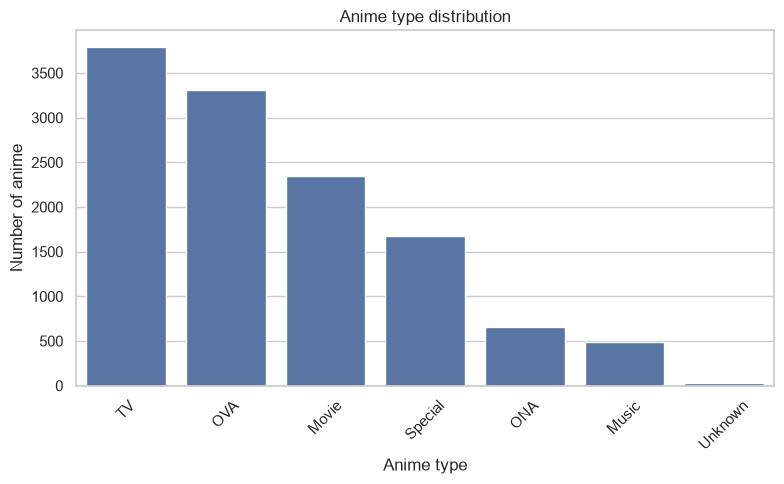

In [28]:
# Anime type distribution
anime_type_counts = (
    anime_final["anime_type"]
    .value_counts()
    .reset_index()
)

anime_type_counts.columns = ["anime_type", "count"]

display(anime_type_counts)

plt.figure(figsize=(8, 5))
sns.barplot(data=anime_type_counts, x="anime_type", y="count")
plt.title("Anime type distribution")
plt.xlabel("Anime type")
plt.ylabel("Number of anime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,genre,count
0,Comedy,4645
1,Action,2845
2,Adventure,2348
3,Fantasy,2309
4,Sci-Fi,2070
5,Drama,2016
6,Shounen,1712
7,Kids,1609
8,Romance,1464
9,School,1220


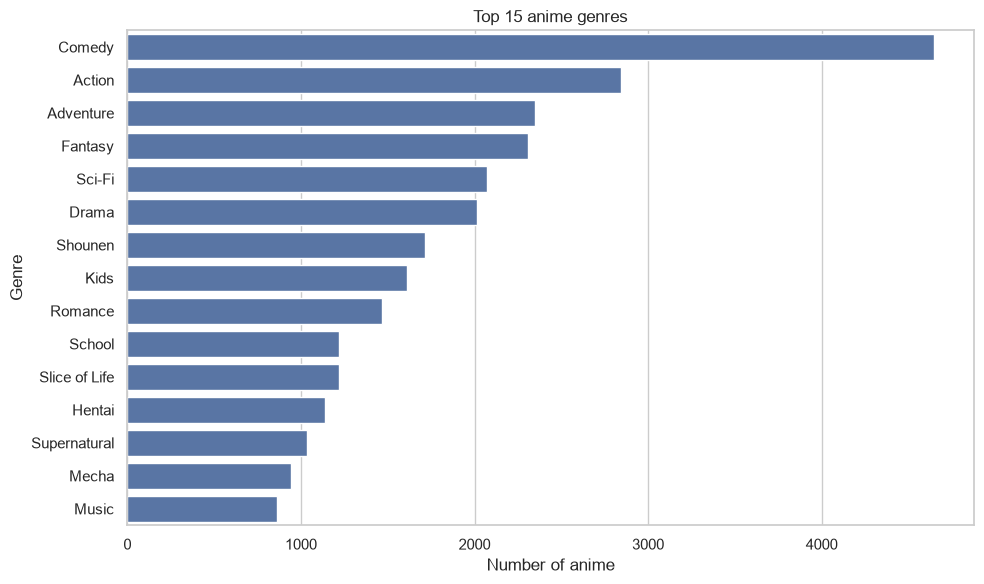

In [29]:
# Genre distribution
genre_exploded = anime_final.copy()
genre_exploded["genre"] = genre_exploded["genre"].str.split(", ")
genre_exploded = genre_exploded.explode("genre")

genre_exploded["genre"] = genre_exploded["genre"].str.strip()

genre_counts = (
    genre_exploded["genre"]
    .value_counts()
    .reset_index()
)

genre_counts.columns = ["genre", "count"]

display(genre_counts.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=genre_counts.head(15), y="genre", x="count")
plt.title("Top 15 anime genres")
plt.xlabel("Number of anime")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

Anime rating summary:


count    12064.000000
mean         6.473902
std          1.026746
min          1.670000
25%          5.880000
50%          6.570000
75%          7.180000
max         10.000000
Name: anime_rating, dtype: float64

Top 10 anime by anime_rating:


,anime_name,genre,anime_type,episodes,anime_rating,member_count
10464,Taka no Tsume 8: Yoshida-kun no X-Files,"Comedy, Parody",Movie,1,10.00,13
10400,Spoon-hime no Swing Kitchen,"Adventure, Kids",TV,Unknown,9.60,47
9595,Mogura no Motoro,Slice of Life,Movie,1,9.50,62
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
9078,Kahei no Umi,Historical,Movie,1,9.33,44
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
10786,Yakusoku: Africa Mizu to Midori,"Drama, Kids",OVA,1,9.25,53
3,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


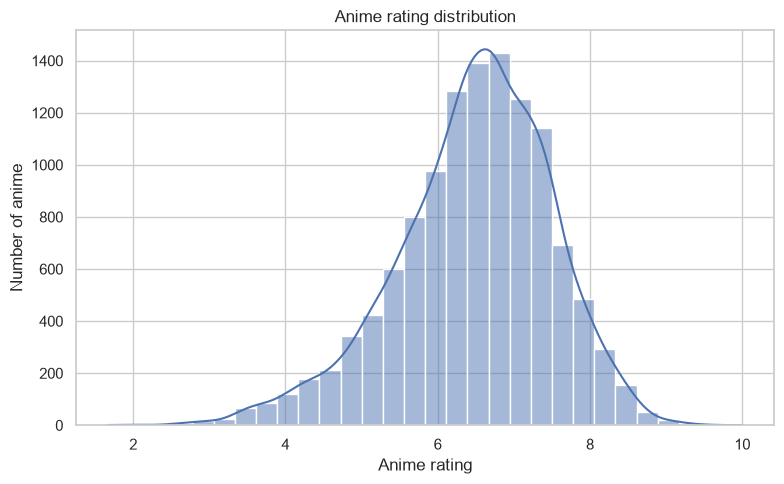

In [30]:
# Anime rating analysis
print("Anime rating summary:")
display(anime_final["anime_rating"].describe())

top_anime_by_rating = (
    anime_final
    .sort_values(by="anime_rating", ascending=False)
    [["anime_name", "genre", "anime_type", "episodes", "anime_rating", "member_count"]]
    .head(10)
)

print("Top 10 anime by anime_rating:")
display(top_anime_by_rating)

plt.figure(figsize=(8, 5))
sns.histplot(anime_final["anime_rating"].dropna(), bins=30, kde=True)
plt.title("Anime rating distribution")
plt.xlabel("Anime rating")
plt.ylabel("Number of anime")
plt.tight_layout()
plt.show()

Member count summary:


count    1.229400e+04
mean     1.807134e+04
std      5.482068e+04
min      5.000000e+00
25%      2.250000e+02
50%      1.550000e+03
75%      9.437000e+03
max      1.013917e+06
Name: member_count, dtype: float64

Top 10 anime by member_count:


,anime_name,genre,anime_type,episodes,anime_rating,member_count
40,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,37,8.71,1013917
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,25,8.54,896229
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,25,7.83,893100
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,13,8.39,717796
19,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,25,8.83,715151
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,220,7.81,683297
3,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,26,8.07,657190
131,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25,8.45,633817


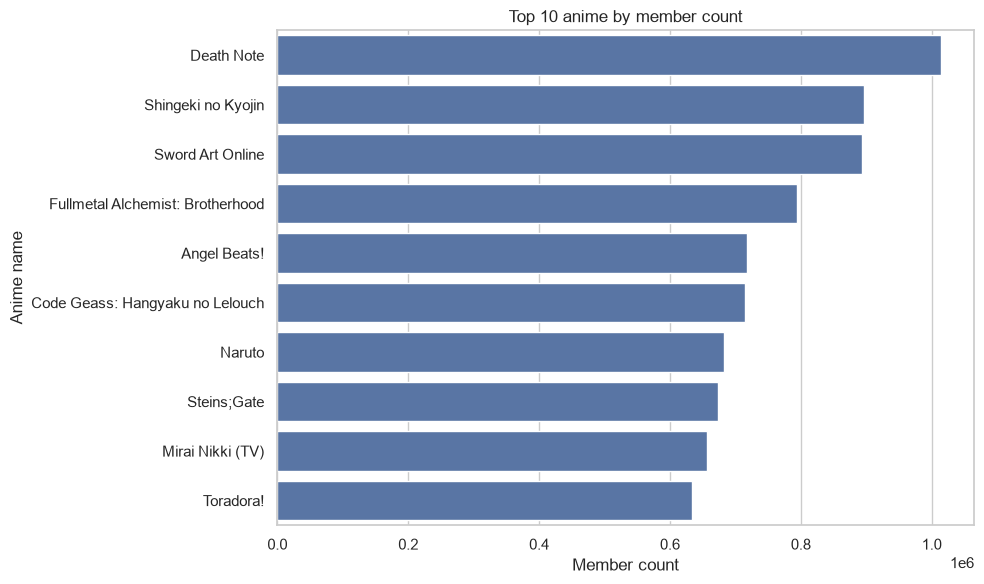

In [31]:
# Popularity analysis using member_count
print("Member count summary:")
display(anime_final["member_count"].describe())

top_anime_by_members = (
    anime_final
    .sort_values(by="member_count", ascending=False)
    [["anime_name", "genre", "anime_type", "episodes", "anime_rating", "member_count"]]
    .head(10)
)

print("Top 10 anime by member_count:")
display(top_anime_by_members)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_anime_by_members,
    y="anime_name",
    x="member_count"
)
plt.title("Top 10 anime by member count")
plt.xlabel("Member count")
plt.ylabel("Anime name")
plt.tight_layout()
plt.show()

Episodes summary for known episode values:


count    11954.000000
mean        12.382550
std         46.865352
min          1.000000
25%          1.000000
50%          2.000000
75%         12.000000
max       1818.000000
Name: episodes_numeric, dtype: float64

Top 10 most common episode values:


,episodes,count
0,1,5677
1,2,1076
2,12,816
3,13,572
4,26,514
5,3,505
6,Unknown,340
7,4,327
8,6,268
9,24,181


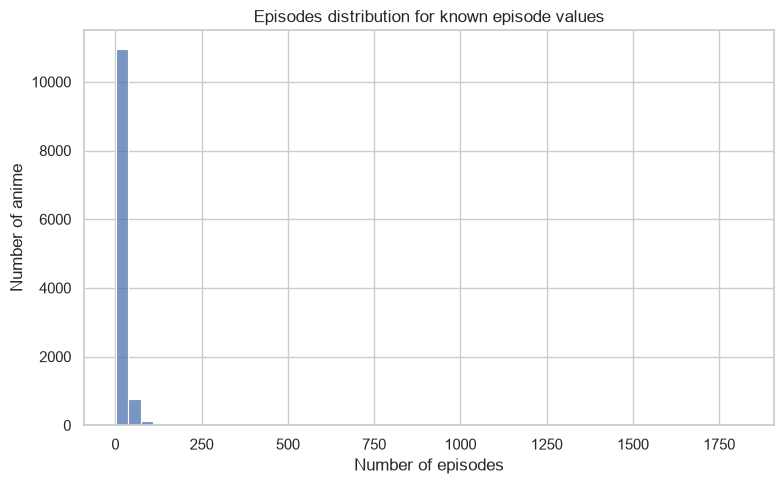

In [32]:
# Episodes analysis
known_episodes = anime_final[anime_final["episodes_numeric"].notnull()].copy()

print("Episodes summary for known episode values:")
display(known_episodes["episodes_numeric"].describe())

top_episode_counts = (
    anime_final["episodes"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_episode_counts.columns = ["episodes", "count"]

print("Top 10 most common episode values:")
display(top_episode_counts)

plt.figure(figsize=(8, 5))
sns.histplot(known_episodes["episodes_numeric"], bins=50)
plt.title("Episodes distribution for known episode values")
plt.xlabel("Number of episodes")
plt.ylabel("Number of anime")
plt.tight_layout()
plt.show()

User rating interaction summary:


,count,mean,std,min,25%,50%,75%,max
total_interactions,12294.0,635.572312,1946.419537,0.0,3.00,37.0,304.00,39340.0
valid_rating_count,12294.0,515.474052,1633.247200,0.0,1.00,26.0,233.00,34226.0
avg_user_rating,9926.0,6.637701,1.298722,1.0,6.07,6.9,7.49,10.0
unrated_count,12294.0,120.098259,319.278956,0.0,1.00,10.0,72.00,5114.0


Top 10 anime by valid user rating count:


,anime_name,genre,anime_type,anime_rating,avg_user_rating,valid_rating_count,total_interactions
40,Death Note,"Mystery, Police, Psychological, Supernatural, ...",TV,8.71,8.83,34226,39340
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",TV,7.83,8.14,26310,30583
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,8.54,8.73,25289,29583
19,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,8.83,8.93,24126,27718
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,8.39,8.55,23565,27183
760,Elfen Lied,"Action, Drama, Horror, Psychological, Romance,...",TV,7.85,8.06,23528,27506
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.81,7.89,22071,25925
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,9.26,9.32,21494,24574
200,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,8.33,8.45,21332,25032
13,Code Geass: Hangyaku no Lelouch R2,"Action, Drama, Mecha, Military, Sci-Fi, Super ...",TV,8.98,9.06,21124,24242


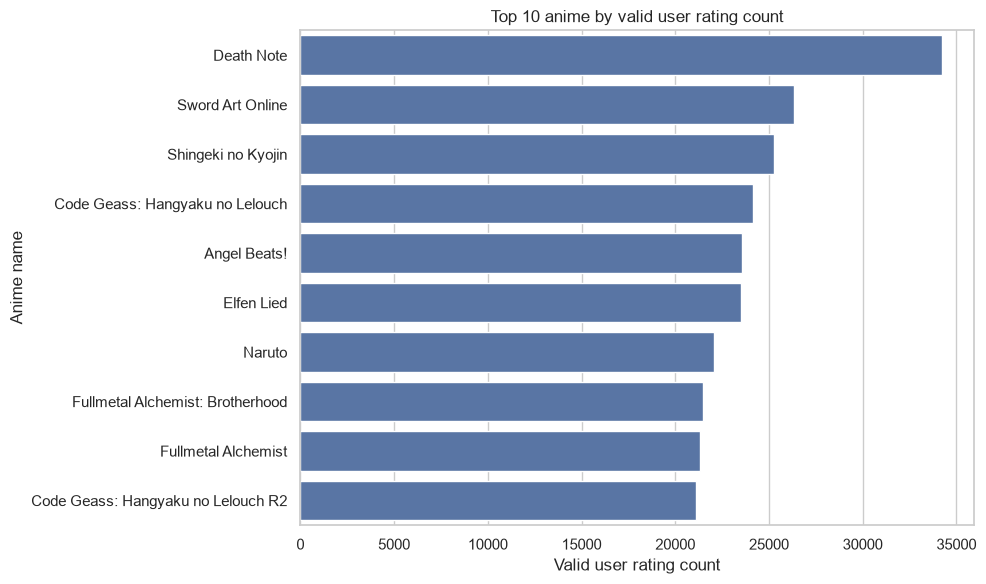

In [33]:
# User rating interaction summary
user_rating_summary_columns = [
    "total_interactions",
    "valid_rating_count",
    "avg_user_rating",
    "unrated_count"
]

print("User rating interaction summary:")
display(anime_final[user_rating_summary_columns].describe().T)

top_anime_by_valid_rating_count = (
    anime_final
    .sort_values(by="valid_rating_count", ascending=False)
    [["anime_name", "genre", "anime_type", "anime_rating", "avg_user_rating", "valid_rating_count", "total_interactions"]]
    .head(10)
)

print("Top 10 anime by valid user rating count:")
display(top_anime_by_valid_rating_count)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_anime_by_valid_rating_count,
    y="anime_name",
    x="valid_rating_count"
)
plt.title("Top 10 anime by valid user rating count")
plt.xlabel("Valid user rating count")
plt.ylabel("Anime name")
plt.tight_layout()
plt.show()

In [34]:
# Compact EDA validation
eda_validation = pd.DataFrame({
    "check": [
        "Rows in anime_final",
        "Columns in anime_final",
        "Genre rows after explode",
        "Anime type categories",
        "Genre categories after explode",
        "Known episode records",
        "Missing anime_rating records",
        "Missing avg_user_rating records"
    ],
    "value": [
        anime_final.shape[0],
        anime_final.shape[1],
        genre_exploded.shape[0],
        anime_final["anime_type"].nunique(),
        genre_exploded["genre"].nunique(),
        known_episodes.shape[0],
        anime_final["anime_rating"].isnull().sum(),
        anime_final["avg_user_rating"].isnull().sum()
    ]
})

display(eda_validation)

,check,value
0,Rows in anime_final,12294
1,Columns in anime_final,13
2,Genre rows after explode,36347
3,Anime type categories,7
4,Genre categories after explode,44
5,Known episode records,11954
6,Missing anime_rating records,230
7,Missing avg_user_rating records,2368


## Step 9 insights

- The final anime-level dataset contains 12,294 anime records and 13 columns.
- Each anime has a unique `anime_id`, and there are no duplicate anime IDs.
- There are 12,292 unique anime names, which means a very small number of anime names may appear more than once with different `anime_id` values.
- The dataset contains 7 anime type categories: TV, OVA, Movie, Special, ONA, Music, and Unknown.
- TV anime has the highest count with 3,787 records, followed by OVA with 3,311 records and Movie with 2,348 records.
- There are 25 anime records with Unknown type. These were retained instead of being deleted because they may still contain useful genre or rating information.
- After splitting multi-genre values, the dataset contains 36,347 genre rows and 44 unique genre categories.
- Comedy is the most common genre with 4,645 records, followed by Action with 2,845, Adventure with 2,348, Fantasy with 2,309, and Sci-Fi with 2,070.
- Genre is an important feature for the content-based recommendation system because anime with similar genres are likely to be recommended together.
- The anime rating column has 12,064 valid values and 230 missing values.
- The average anime rating is approximately 6.47, with most anime ratings between 5.88 and 7.18.
- The anime rating distribution is concentrated around the 6 to 7.5 range.
- Some anime with very high raw ratings have very low member counts. Therefore, raw anime rating should not be interpreted alone; it should be considered together with popularity or user rating count.
- The `member_count` column shows strong popularity differences across anime. The median member count is 1,550, while the maximum member count is 1,013,917.
- Death Note has the highest member count, followed by Shingeki no Kyojin, Sword Art Online, and Fullmetal Alchemist: Brotherhood.
- The episodes column is highly uneven. Most anime have very few episodes, with 1 episode being the most common value.
- There are 11,954 anime with known episode values and 340 anime with Unknown episode values.
- The maximum known episode count is 1,818, which shows that episode count has extreme values and should be handled carefully later during distribution/skewness analysis.
- The user rating interaction summary shows that some anime have very high interaction counts, while many have very low or no interactions.
- Death Note has the highest valid user rating count, followed by Sword Art Online and Shingeki no Kyojin.
- `avg_user_rating`, `valid_rating_count`, `total_interactions`, and `member_count` are useful for EDA, filtering, ranking, and app display, but they will not be the core content-similarity features.
- The content-based recommender should mainly use anime content fields such as `genre`, `anime_type`, and possibly episode-based information.

----

# Step 10: Distribution and skewness analysis

In this step, we check the distribution and skewness of important numerical columns.
The assignment specifically asks us to check distributions and skewness in the variables.

We will analyze:
- `episodes_numeric`
- `anime_rating`
- `member_count`
- `total_interactions`
- `valid_rating_count`
- `avg_user_rating`
- `unrated_count`


In [35]:
# Distribution and skewness summary
skewness_columns = [
    "episodes_numeric",
    "anime_rating",
    "member_count",
    "total_interactions",
    "valid_rating_count",
    "avg_user_rating",
    "unrated_count"
]

def classify_skewness(skew_value):
    if pd.isna(skew_value):
        return "Not available"
    elif abs(skew_value) < 0.5:
        return "Approximately symmetric"
    elif abs(skew_value) < 1:
        return "Moderately skewed"
    else:
        return "Highly skewed"

skewness_summary = pd.DataFrame({
    "column": skewness_columns,
    "non_null_count": [anime_final[col].notnull().sum() for col in skewness_columns],
    "missing_count": [anime_final[col].isnull().sum() for col in skewness_columns],
    "mean": [anime_final[col].mean() for col in skewness_columns],
    "median": [anime_final[col].median() for col in skewness_columns],
    "min": [anime_final[col].min() for col in skewness_columns],
    "max": [anime_final[col].max() for col in skewness_columns],
    "skewness": [anime_final[col].skew() for col in skewness_columns]
})

skewness_summary["skewness"] = skewness_summary["skewness"].round(2)
skewness_summary["mean"] = skewness_summary["mean"].round(2)
skewness_summary["median"] = skewness_summary["median"].round(2)
skewness_summary["min"] = skewness_summary["min"].round(2)
skewness_summary["max"] = skewness_summary["max"].round(2)

skewness_summary["skewness_interpretation"] = skewness_summary["skewness"].apply(classify_skewness)

display(skewness_summary)

,column,non_null_count,missing_count,mean,median,min,max,skewness,skewness_interpretation
0,episodes_numeric,11954,340,12.38,2.00,1.00,1818.0,23.39,Highly skewed
1,anime_rating,12064,230,6.47,6.57,1.67,10.0,-0.54,Moderately skewed
2,member_count,12294,0,18071.34,1550.00,5.00,1013917.0,6.68,Highly skewed
3,total_interactions,12294,0,635.57,37.00,0.00,39340.0,6.70,Highly skewed
4,valid_rating_count,12294,0,515.47,26.00,0.00,34226.0,7.00,Highly skewed
5,avg_user_rating,9926,2368,6.64,6.90,1.00,10.0,-1.27,Highly skewed
6,unrated_count,12294,0,120.10,10.00,0.00,5114.0,5.33,Highly skewed


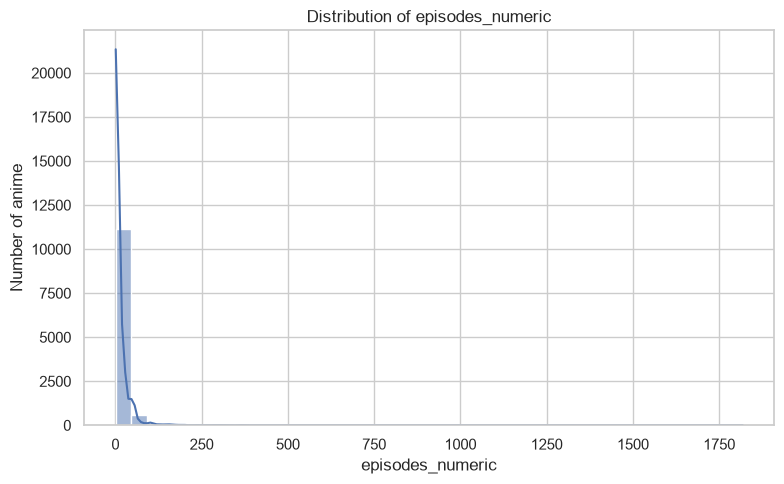

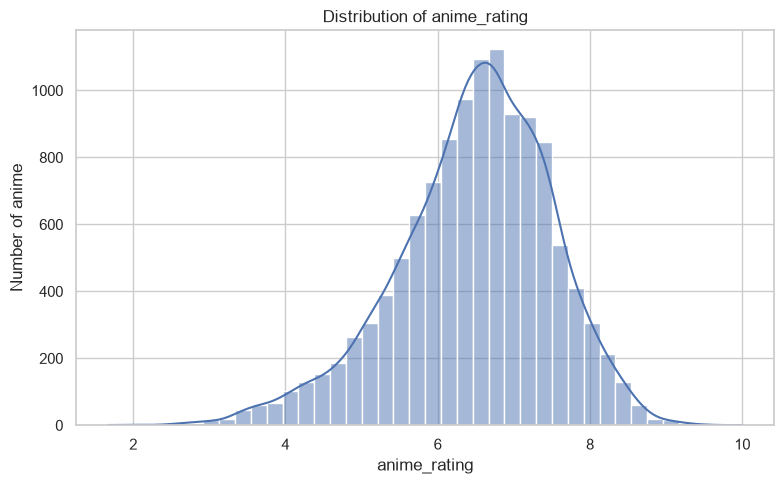

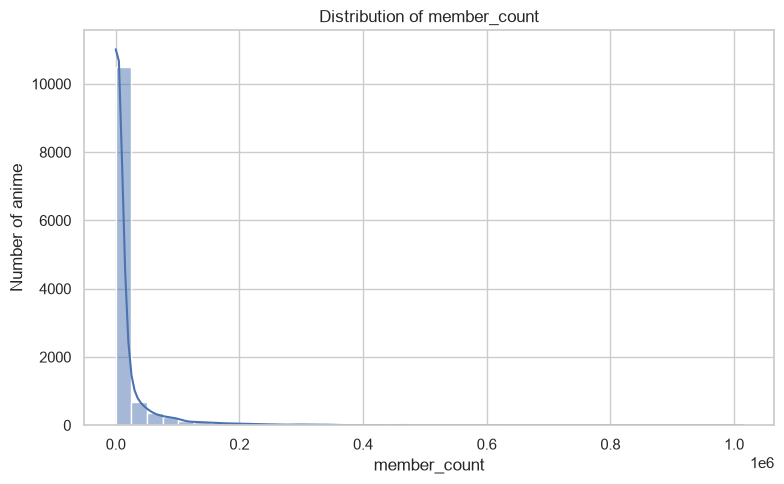

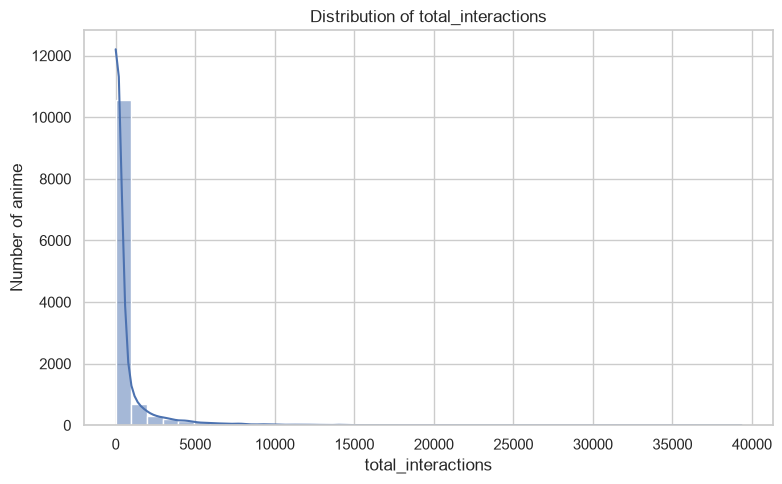

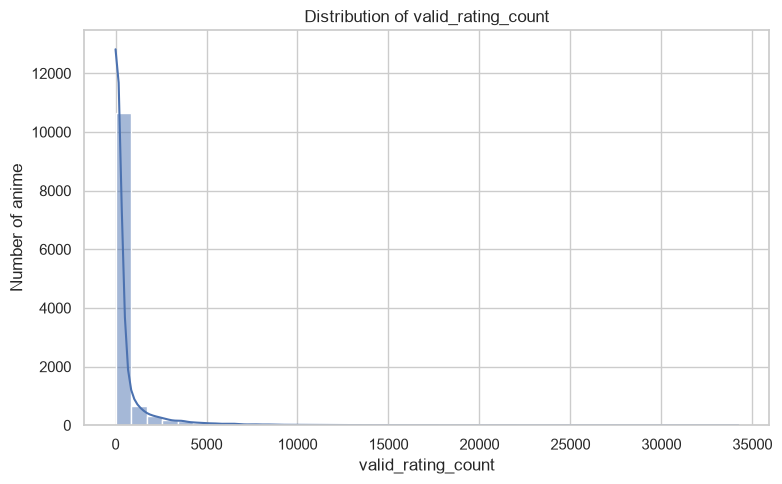

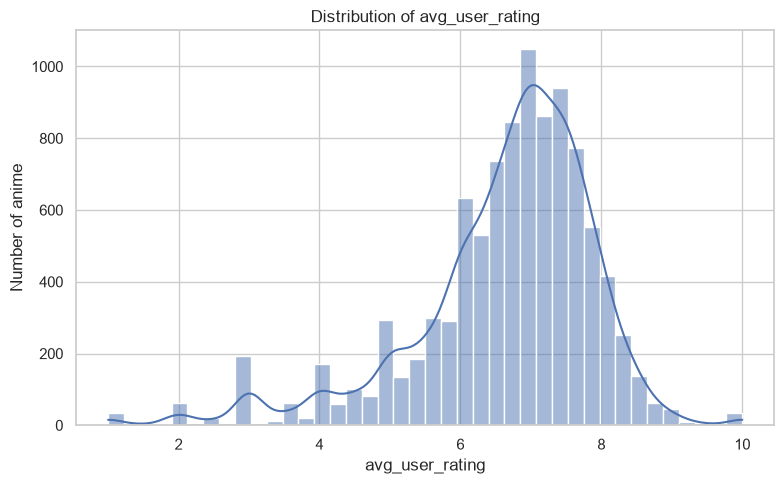

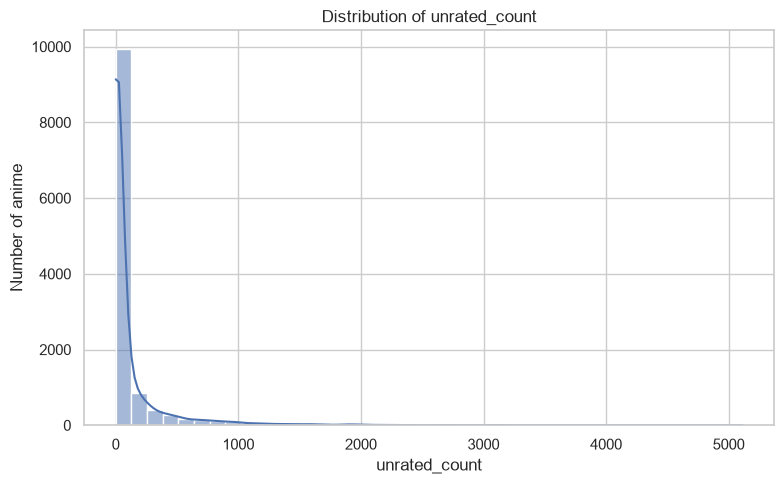

In [36]:
# Plot distributions for numerical columns
for col in skewness_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(anime_final[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of anime")
    plt.tight_layout()
    plt.show()

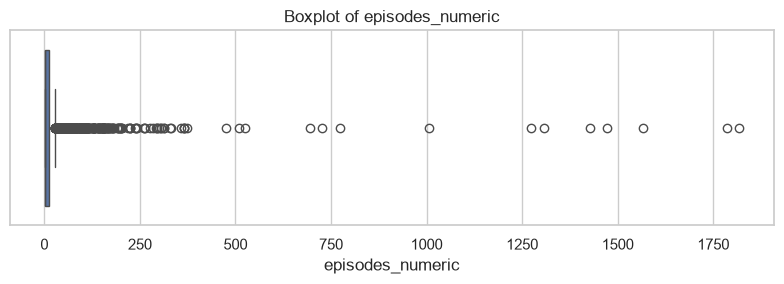

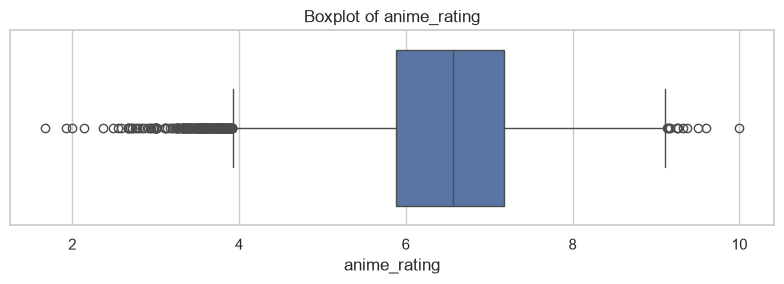

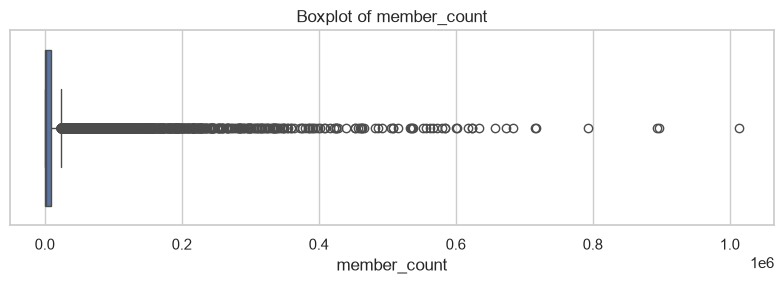

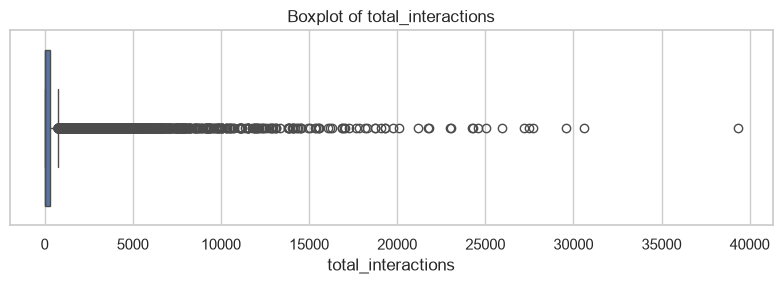

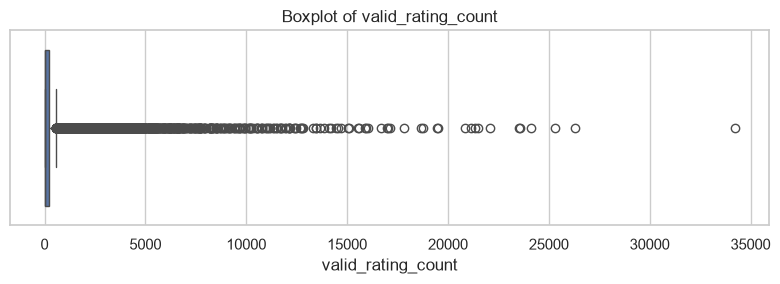

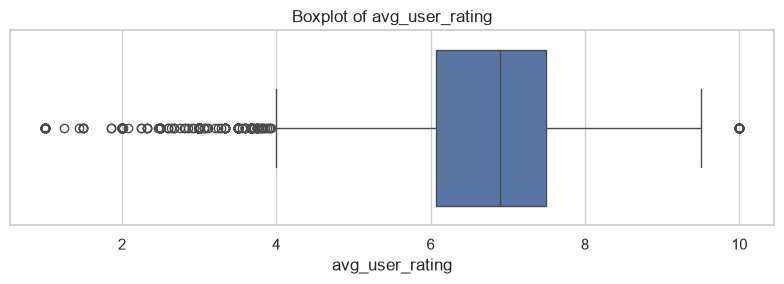

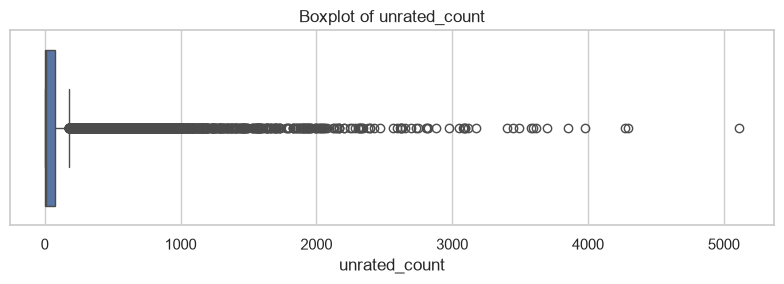

In [37]:
# Plot boxplots for numerical columns
for col in skewness_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=anime_final[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [38]:
# Validate distribution and skewness analysis
distribution_validation = pd.DataFrame({
    "check": [
        "Rows in anime_final",
        "Number of numerical columns analyzed",
        "Columns analyzed",
        "Missing values in episodes_numeric",
        "Missing values in anime_rating",
        "Missing values in avg_user_rating"
    ],
    "value": [
        anime_final.shape[0],
        len(skewness_columns),
        ", ".join(skewness_columns),
        anime_final["episodes_numeric"].isnull().sum(),
        anime_final["anime_rating"].isnull().sum(),
        anime_final["avg_user_rating"].isnull().sum()
    ]
})

display(distribution_validation)

,check,value
0,Rows in anime_final,12294
1,Number of numerical columns analyzed,7
2,Columns analyzed,"episodes_numeric, anime_rating, member_count, ..."
3,Missing values in episodes_numeric,340
4,Missing values in anime_rating,230
5,Missing values in avg_user_rating,2368


## Step 10 insights

- Seven numerical columns were analyzed for distribution and skewness: `episodes_numeric`, `anime_rating`, `member_count`, `total_interactions`, `valid_rating_count`, `avg_user_rating`, and `unrated_count`.
- `episodes_numeric` is highly right-skewed with a skewness value of 23.39. Most anime have very few episodes, but a few anime have extremely high episode counts.
- `anime_rating` is moderately left-skewed with a skewness value of -0.54. Most anime ratings are concentrated around the 6 to 7.5 range.
- `member_count` is highly right-skewed with a skewness value of 6.68. Most anime have relatively low member counts, while a small number of very popular anime have extremely high member counts.
- `total_interactions` and `valid_rating_count` are also highly right-skewed. This means user interactions are concentrated around a small number of popular anime.
- `avg_user_rating` is highly left-skewed with a skewness value of -1.27. Most average user ratings are on the higher side, but some anime have much lower average user ratings.
- `unrated_count` is highly right-skewed, showing that a few anime have many unrated interactions.
- The boxplots show many statistical outliers in `episodes_numeric`, `member_count`, `total_interactions`, `valid_rating_count`, and `unrated_count`.
- These outliers are expected in recommendation datasets because some anime are naturally much more popular or much longer than others.
- Since this is a content-based recommendation system, these skewed numeric columns should not be blindly transformed or removed.
- Popularity and rating-related columns are useful for EDA, filtering, ranking, and app display, but they should not dominate the core content-based similarity logic.
- Transformation decisions will be made carefully in the next step based on whether each column is used for modelling, display, filtering, or only EDA.

---

# Step 11: Transformation decision

In this step, we decide whether transformations are required based on the distribution and skewness analysis.
The assignment asks us to check distributions and skewness and apply transformations only if required.

For this project:
- Highly skewed popularity and interaction columns will not be transformed because they are used mainly for EDA, filtering, ranking, and app display.
- Anime rating columns will not be transformed because they are not used as core content-similarity features.
- `episodes_numeric` is highly skewed, so we will convert it into an interpretable episode category instead of using raw episode numbers directly.

This keeps the recommendation system content-based, simple, and explainable.

In [39]:
# Create transformation decision table
transformation_decision = pd.DataFrame({
    "column": [
        "episodes_numeric",
        "anime_rating",
        "member_count",
        "total_interactions",
        "valid_rating_count",
        "avg_user_rating",
        "unrated_count"
    ],
    "skewness": [
        skewness_summary.loc[skewness_summary["column"] == "episodes_numeric", "skewness"].values[0],
        skewness_summary.loc[skewness_summary["column"] == "anime_rating", "skewness"].values[0],
        skewness_summary.loc[skewness_summary["column"] == "member_count", "skewness"].values[0],
        skewness_summary.loc[skewness_summary["column"] == "total_interactions", "skewness"].values[0],
        skewness_summary.loc[skewness_summary["column"] == "valid_rating_count", "skewness"].values[0],
        skewness_summary.loc[skewness_summary["column"] == "avg_user_rating", "skewness"].values[0],
        skewness_summary.loc[skewness_summary["column"] == "unrated_count", "skewness"].values[0]
    ],
    "usage_in_project": [
        "Possible content feature",
        "EDA, filtering, app display",
        "EDA, popularity analysis, app display",
        "EDA, interaction analysis, app display",
        "EDA, interaction analysis, app display",
        "EDA, user rating context, app display",
        "EDA, interaction analysis"
    ],
    "transformation_decision": [
        "Create episode_category",
        "No transformation",
        "No transformation",
        "No transformation",
        "No transformation",
        "No transformation",
        "No transformation"
    ],
    "reason": [
        "Raw episode counts are highly skewed. Binning makes this feature more interpretable for content-based similarity.",
        "Anime rating is not a core similarity feature and will be used mainly for display/filtering.",
        "Popularity is highly skewed but should not drive content similarity.",
        "Interaction count is user-behavior data, not anime content.",
        "Valid rating count is user-behavior data, not anime content.",
        "Average user rating is useful context but not a content feature.",
        "Unrated count is user-behavior data and not useful for content similarity."
    ]
})

display(transformation_decision)

,column,skewness,usage_in_project,transformation_decision,reason
0,episodes_numeric,23.39,Possible content feature,Create episode_category,Raw episode counts are highly skewed. Binning ...
1,anime_rating,-0.54,"EDA, filtering, app display",No transformation,Anime rating is not a core similarity feature ...
2,member_count,6.68,"EDA, popularity analysis, app display",No transformation,Popularity is highly skewed but should not dri...
3,total_interactions,6.70,"EDA, interaction analysis, app display",No transformation,"Interaction count is user-behavior data, not a..."
4,valid_rating_count,7.00,"EDA, interaction analysis, app display",No transformation,"Valid rating count is user-behavior data, not ..."
5,avg_user_rating,-1.27,"EDA, user rating context, app display",No transformation,Average user rating is useful context but not ...
6,unrated_count,5.33,"EDA, interaction analysis",No transformation,Unrated count is user-behavior data and not us...


In [40]:
# Create dataframe for transformed/prepared anime data
anime_prepared = anime_final.copy()

# Function to convert episode counts into interpretable categories
def create_episode_category(episodes_numeric):
    if pd.isna(episodes_numeric):
        return "Unknown episodes"
    elif episodes_numeric == 1:
        return "Single episode"
    elif episodes_numeric <= 12:
        return "Short series"
    elif episodes_numeric <= 26:
        return "Medium series"
    elif episodes_numeric <= 52:
        return "Long series"
    else:
        return "Very long series"

anime_prepared["episode_category"] = anime_prepared["episodes_numeric"].apply(create_episode_category)

print("episode_category created successfully.")
print("anime_final shape:", anime_final.shape)
print("anime_prepared shape:", anime_prepared.shape)

display(
    anime_prepared[
        ["anime_name", "episodes", "episodes_numeric", "episode_category"]
    ].head(10)
)

episode_category created successfully.
anime_final shape: (12294, 13)
anime_prepared shape: (12294, 14)


,anime_name,episodes,episodes_numeric,episode_category
0,Kimi no Na wa.,1,1.0,Single episode
1,Fullmetal Alchemist: Brotherhood,64,64.0,Very long series
2,Gintama°,51,51.0,Long series
3,Steins;Gate,24,24.0,Medium series
4,Gintama',51,51.0,Long series
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,10,10.0,Short series
6,Hunter x Hunter (2011),148,148.0,Very long series
7,Ginga Eiyuu Densetsu,110,110.0,Very long series
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,1,1.0,Single episode
9,Gintama': Enchousen,13,13.0,Medium series


,episode_category,count
0,Single episode,5677
1,Short series,3471
2,Medium series,1661
3,Long series,803
4,Very long series,342
5,Unknown episodes,340


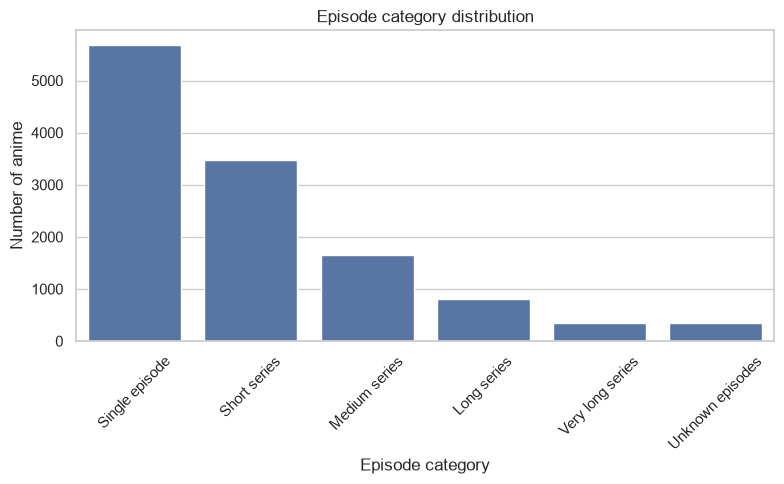

In [41]:
# Check episode category distribution
episode_category_counts = (
    anime_prepared["episode_category"]
    .value_counts()
    .reset_index()
)

episode_category_counts.columns = ["episode_category", "count"]

display(episode_category_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=episode_category_counts,
    x="episode_category",
    y="count"
)
plt.title("Episode category distribution")
plt.xlabel("Episode category")
plt.ylabel("Number of anime")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
# Validate transformation decision
transformation_validation = pd.DataFrame({
    "check": [
        "Rows in anime_final",
        "Rows in anime_prepared",
        "Columns in anime_final",
        "Columns in anime_prepared",
        "Missing episode_category values",
        "Unknown episodes in episode_category",
        "Missing episodes_numeric values",
        "Episode category count total"
    ],
    "value": [
        anime_final.shape[0],
        anime_prepared.shape[0],
        anime_final.shape[1],
        anime_prepared.shape[1],
        anime_prepared["episode_category"].isnull().sum(),
        (anime_prepared["episode_category"] == "Unknown episodes").sum(),
        anime_prepared["episodes_numeric"].isnull().sum(),
        episode_category_counts["count"].sum()
    ]
})

display(transformation_validation)

,check,value
0,Rows in anime_final,12294
1,Rows in anime_prepared,12294
2,Columns in anime_final,13
3,Columns in anime_prepared,14
4,Missing episode_category values,0
5,Unknown episodes in episode_category,340
6,Missing episodes_numeric values,340
7,Episode category count total,12294


## Step 11 insights

- The distribution and skewness analysis showed that several numerical columns are highly skewed.
- The only transformation applied in this step was converting `episodes_numeric` into an interpretable categorical feature called `episode_category`.
- This decision was made because raw episode counts are highly right-skewed and difficult to use directly in a content-based recommender.
- The new `episode_category` column groups anime into six categories: Single episode, Short series, Medium series, Long series, Very long series, and Unknown episodes.
- Most anime are either Single episode or Short series.
- The dataset has 5,677 Single episode anime and 3,471 Short series anime.
- There are 340 anime records with Unknown episodes, matching the missing values in `episodes_numeric`.
- No rows were deleted during this step. `anime_prepared` still has 12,294 rows.
- No transformation was applied to `anime_rating`, `member_count`, `total_interactions`, `valid_rating_count`, `avg_user_rating`, or `unrated_count`.
- These columns are useful for EDA, filtering, ranking, and app display, but they are not core content-similarity features.
- This keeps the recommendation system aligned with the assignment requirement of building a content-based recommender system.

---

# Step 12: Feature selection

In this step, we select the final features for the content-based recommendation system.
A content-based recommender should recommend anime based on anime attributes, not based on user behavior.
For this project, the core content features selected are:
- `genre`
- `anime_type`
- `episode_category`

Rating, popularity, and user-interaction columns will not be used as core similarity features. They will be retained for EDA, filtering, ranking, explanation, and app display.

In [43]:
# Create feature selection decision table
feature_selection_decision = pd.DataFrame({
    "column": [
        "genre",
        "anime_type",
        "episode_category",
        "anime_rating",
        "member_count",
        "avg_user_rating",
        "valid_rating_count",
        "total_interactions",
        "unrated_count"
    ],
    "selected_for_similarity": [
        "Yes",
        "Yes",
        "Yes",
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ],
    "usage": [
        "Core content feature",
        "Core content feature",
        "Supporting content/profile feature",
        "Display/filtering support",
        "Popularity display/filtering support",
        "User rating context for display",
        "Reliability/popularity context",
        "Interaction/popularity context",
        "EDA only"
    ],
    "reason": [
        "Genre describes the anime content and is the strongest feature for similarity.",
        "Anime type describes format such as TV, Movie, OVA, etc.",
        "Episode category gives profile-level information without using skewed raw episode counts.",
        "Rating is useful for display but should not define content similarity.",
        "Popularity should not drive content similarity.",
        "Average user rating is user-behavior context, not anime content.",
        "Rating count is user-behavior context, not anime content.",
        "Total interactions represent user activity, not anime content.",
        "Unrated count is not useful for content similarity."
    ]
})

display(feature_selection_decision)

,column,selected_for_similarity,usage,reason
0,genre,Yes,Core content feature,Genre describes the anime content and is the s...
1,anime_type,Yes,Core content feature,"Anime type describes format such as TV, Movie,..."
2,episode_category,Yes,Supporting content/profile feature,Episode category gives profile-level informati...
3,anime_rating,No,Display/filtering support,Rating is useful for display but should not de...
4,member_count,No,Popularity display/filtering support,Popularity should not drive content similarity.
5,avg_user_rating,No,User rating context for display,"Average user rating is user-behavior context, ..."
6,valid_rating_count,No,Reliability/popularity context,"Rating count is user-behavior context, not ani..."
7,total_interactions,No,Interaction/popularity context,"Total interactions represent user activity, no..."
8,unrated_count,No,EDA only,Unrated count is not useful for content simila...


In [44]:
# Define selected content-based features
selected_content_features = [
    "genre",
    "anime_type",
    "episode_category"
]

supporting_display_features = [
    "anime_id",
    "anime_name",
    "anime_rating",
    "member_count",
    "avg_user_rating",
    "valid_rating_count",
    "total_interactions"
]

print("Selected content features for recommendation:")
print(selected_content_features)

print("\nSupporting display/filtering features:")
print(supporting_display_features)

Selected content features for recommendation:
['genre', 'anime_type', 'episode_category']

Supporting display/filtering features:
['anime_id', 'anime_name', 'anime_rating', 'member_count', 'avg_user_rating', 'valid_rating_count', 'total_interactions']


In [45]:
# Preview selected content features
content_feature_preview = anime_prepared[
    ["anime_name"] + selected_content_features + supporting_display_features[2:]
].head(10)

display(content_feature_preview)

,anime_name,genre,anime_type,episode_category,anime_rating,member_count,avg_user_rating,valid_rating_count,total_interactions
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,Single episode,9.37,200630,9.43,1961,2199
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,Very long series,9.26,793665,9.32,21494,24574
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,Long series,9.25,114262,9.45,1188,1386
3,Steins;Gate,"Sci-Fi, Thriller",TV,Medium series,9.17,673572,9.26,17151,19283
4,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",TV,Long series,9.16,151266,9.27,3115,3673
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,Short series,9.15,93351,9.17,1038,1233
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,Very long series,9.13,425855,9.23,7477,8575
7,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,Very long series,9.11,80679,9.39,803,903
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,Single episode,9.10,72534,9.19,2147,2525
9,Gintama': Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,Medium series,9.11,81109,9.20,2126,2537


In [46]:
# Validate feature selection
all_required_features = selected_content_features + supporting_display_features

missing_features = [
    col for col in all_required_features if col not in anime_prepared.columns
]

feature_selection_validation = pd.DataFrame({
    "check": [
        "Rows in anime_prepared",
        "Columns in anime_prepared",
        "Selected content features count",
        "Supporting display features count",
        "Missing required features",
        "Missing genre values",
        "Missing anime_type values",
        "Missing episode_category values"
    ],
    "value": [
        anime_prepared.shape[0],
        anime_prepared.shape[1],
        len(selected_content_features),
        len(supporting_display_features),
        len(missing_features),
        anime_prepared["genre"].isnull().sum(),
        anime_prepared["anime_type"].isnull().sum(),
        anime_prepared["episode_category"].isnull().sum()
    ]
})

display(feature_selection_validation)

print("Missing required features:", missing_features)

,check,value
0,Rows in anime_prepared,12294
1,Columns in anime_prepared,14
2,Selected content features count,3
3,Supporting display features count,7
4,Missing required features,0
5,Missing genre values,0
6,Missing anime_type values,0
7,Missing episode_category values,0


Missing required features: []


## Step 12 insights

- The final content-based recommendation features selected are `genre`, `anime_type`, and `episode_category`.
- `genre` is selected because it directly describes anime content and is the strongest similarity feature in this dataset.
- `anime_type` is selected because it captures the anime format, such as TV, Movie, OVA, Special, ONA, Music, or Unknown.
- `episode_category` is selected as a supporting profile feature because it represents episode length in an interpretable way without using highly skewed raw episode counts.
- Rating, popularity, and user-interaction columns were not selected for core similarity calculation.
- `anime_rating`, `member_count`, `avg_user_rating`, `valid_rating_count`, and `total_interactions` will be retained for display, filtering, ranking support, and app output.
- User-behavior columns are useful context, but they should not define similarity in this project because the assignment requires a content-based recommender system.
- The selected content features have no missing values, so they are ready for building the combined content profile.
- The feature selection validation confirms that all required features are present in `anime_prepared`.

----

# Step 13: Build content profile

In this step, we create a combined text profile for each anime.
The content profile will combine the selected content-based features:
- `genre`
- `anime_type`
- `episode_category`

This combined profile will represent each anime using its content attributes. It will be used in the next step for text vectorization.

In [47]:
# Create modelling dataframe
anime_model_data = anime_prepared.copy()

print("anime_model_data created successfully.")
print("anime_model_data shape:", anime_model_data.shape)

anime_model_data created successfully.
anime_model_data shape: (12294, 14)


In [48]:
# Clean selected content fields before creating content profile
def clean_text_value(value):
    if pd.isna(value):
        return ""
    
    value = str(value).lower()
    value = value.replace(",", " ")
    value = value.replace("-", " ")
    value = value.replace("/", " ")
    value = " ".join(value.split())
    
    return value

anime_model_data["genre_clean"] = anime_model_data["genre"].apply(clean_text_value)
anime_model_data["anime_type_clean"] = anime_model_data["anime_type"].apply(clean_text_value)
anime_model_data["episode_category_clean"] = anime_model_data["episode_category"].apply(clean_text_value)

display(
    anime_model_data[
        [
            "anime_name",
            "genre",
            "genre_clean",
            "anime_type",
            "anime_type_clean",
            "episode_category",
            "episode_category_clean"
        ]
    ].head(10)
)

,anime_name,genre,genre_clean,anime_type,anime_type_clean,episode_category,episode_category_clean
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",drama romance school supernatural,Movie,movie,Single episode,single episode
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",action adventure drama fantasy magic military ...,TV,tv,Very long series,very long series
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",action comedy historical parody samurai sci fi...,TV,tv,Long series,long series
3,Steins;Gate,"Sci-Fi, Thriller",sci fi thriller,TV,tv,Medium series,medium series
4,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",action comedy historical parody samurai sci fi...,TV,tv,Long series,long series
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",comedy drama school shounen sports,TV,tv,Short series,short series
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",action adventure shounen super power,TV,tv,Very long series,very long series
7,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",drama military sci fi space,OVA,ova,Very long series,very long series
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",action comedy historical parody samurai sci fi...,Movie,movie,Single episode,single episode
9,Gintama': Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",action comedy historical parody samurai sci fi...,TV,tv,Medium series,medium series


In [49]:
# Create combined content profile
anime_model_data["content_profile"] = (
    anime_model_data["genre_clean"] + " " +
    anime_model_data["anime_type_clean"] + " " +
    anime_model_data["episode_category_clean"]
)

# Remove extra spaces if any
anime_model_data["content_profile"] = anime_model_data["content_profile"].apply(
    lambda x: " ".join(x.split())
)

print("content_profile created successfully.")

display(
    anime_model_data[
        ["anime_name", "genre", "anime_type", "episode_category", "content_profile"]
    ].head(10)
)

content_profile created successfully.


,anime_name,genre,anime_type,episode_category,content_profile
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,Single episode,drama romance school supernatural movie single...
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,Very long series,action adventure drama fantasy magic military ...
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,Long series,action comedy historical parody samurai sci fi...
3,Steins;Gate,"Sci-Fi, Thriller",TV,Medium series,sci fi thriller tv medium series
4,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",TV,Long series,action comedy historical parody samurai sci fi...
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,Short series,comedy drama school shounen sports tv short se...
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,Very long series,action adventure shounen super power tv very l...
7,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,Very long series,drama military sci fi space ova very long series
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,Single episode,action comedy historical parody samurai sci fi...
9,Gintama': Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,Medium series,action comedy historical parody samurai sci fi...


In [50]:
# Validate content profile
content_profile_validation = pd.DataFrame({
    "check": [
        "Rows in anime_model_data",
        "Columns in anime_model_data",
        "Missing genre_clean values",
        "Missing anime_type_clean values",
        "Missing episode_category_clean values",
        "Missing content_profile values",
        "Empty content_profile values",
        "Unique content_profile values"
    ],
    "value": [
        anime_model_data.shape[0],
        anime_model_data.shape[1],
        anime_model_data["genre_clean"].isnull().sum(),
        anime_model_data["anime_type_clean"].isnull().sum(),
        anime_model_data["episode_category_clean"].isnull().sum(),
        anime_model_data["content_profile"].isnull().sum(),
        (anime_model_data["content_profile"].str.strip() == "").sum(),
        anime_model_data["content_profile"].nunique()
    ]
})

display(content_profile_validation)

,check,value
0,Rows in anime_model_data,12294
1,Columns in anime_model_data,18
2,Missing genre_clean values,0
3,Missing anime_type_clean values,0
4,Missing episode_category_clean values,0
5,Missing content_profile values,0
6,Empty content_profile values,0
7,Unique content_profile values,6008


## Step 13 insights

- A modelling dataframe called `anime_model_data` was created from `anime_prepared`.
- The selected content fields `genre`, `anime_type`, and `episode_category` were cleaned into lowercase text fields.
- Special separators such as commas, hyphens, and slashes were replaced with spaces to make the text easier for vectorization.
- A new `content_profile` column was created by combining `genre_clean`, `anime_type_clean`, and `episode_category_clean`.
- The `content_profile` represents each anime using its content attributes.
- No rating, popularity, or user-interaction columns were included in the `content_profile`.
- The final `anime_model_data` has 12,294 rows and 18 columns.
- There are no missing or empty values in `content_profile`.
- The dataset has 6,008 unique content profiles, meaning some anime share the same genre, type, and episode-category combination.
- This is expected in a content-based recommender because multiple anime can have similar content attributes.
- The content profiles are now ready for TF-IDF vectorization.

----

# Step 14: Vectorization

In this step, we convert the text-based `content_profile` into numerical vectors using TF-IDF Vectorization.
TF-IDF helps represent each anime based on the importance of words in its content profile.

The vectorized matrix will be used in the next step to calculate cosine similarity between anime.

In [51]:
# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(anime_model_data["content_profile"])

print("TF-IDF vectorization completed successfully.")
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Number of anime records:", anime_model_data.shape[0])
print("Number of TF-IDF features:", len(tfidf_vectorizer.get_feature_names_out()))

TF-IDF vectorization completed successfully.
TF-IDF matrix shape: (12294, 941)
Number of anime records: 12294
Number of TF-IDF features: 941


In [52]:
# Preview TF-IDF feature names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("First 30 TF-IDF features:")
print(tfidf_feature_names[:30])

print("\nLast 30 TF-IDF features:")
print(tfidf_feature_names[-30:])

First 30 TF-IDF features:
['action' 'action adventure' 'action cars' 'action comedy'
 'action dementia' 'action demons' 'action drama' 'action ecchi'
 'action fantasy' 'action game' 'action harem' 'action hentai'
 'action historical' 'action horror' 'action josei' 'action kids'
 'action magic' 'action martial' 'action mecha' 'action military'
 'action movie' 'action music' 'action mystery' 'action ona' 'action ova'
 'action parody' 'action police' 'action psychological' 'action romance'
 'action samurai']

Last 30 TF-IDF features:
['tv unknown' 'tv very' 'unknown' 'unknown episodes' 'unknown movie'
 'unknown ona' 'unknown ova' 'unknown special' 'unknown tv'
 'unknown unknown' 'vampire' 'vampire movie' 'vampire music' 'vampire ona'
 'vampire ova' 'vampire special' 'vampire tv' 'vampire yaoi' 'very'
 'very long' 'yaoi' 'yaoi ona' 'yaoi ova' 'yaoi special' 'yaoi unknown'
 'yuri' 'yuri ona' 'yuri ova' 'yuri special' 'yuri unknown']


In [53]:
# Preview a small sample of the TF-IDF matrix
tfidf_sample = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=tfidf_feature_names
)

display(tfidf_sample.iloc[:, :20])

,action,action adventure,action cars,action comedy,action dementia,action demons,action drama,action ecchi,action fantasy,action game,action harem,action hentai,action historical,action horror,action josei,action kids,action magic,action martial,action mecha,action military
0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.126698,0.186372,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.124091,0.000000,0.0,0.208668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.124091,0.000000,0.0,0.208668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
# Validate vectorization
vectorization_validation = pd.DataFrame({
    "check": [
        "Rows in anime_model_data",
        "Rows in TF-IDF matrix",
        "Content profile records",
        "Missing content_profile values",
        "Empty content_profile values",
        "Number of TF-IDF features",
        "TF-IDF matrix type"
    ],
    "value": [
        anime_model_data.shape[0],
        tfidf_matrix.shape[0],
        anime_model_data["content_profile"].shape[0],
        anime_model_data["content_profile"].isnull().sum(),
        (anime_model_data["content_profile"].str.strip() == "").sum(),
        tfidf_matrix.shape[1],
        type(tfidf_matrix).__name__
    ]
})

display(vectorization_validation)

,check,value
0,Rows in anime_model_data,12294
1,Rows in TF-IDF matrix,12294
2,Content profile records,12294
3,Missing content_profile values,0
4,Empty content_profile values,0
5,Number of TF-IDF features,941
6,TF-IDF matrix type,csr_matrix


## Step 14 insights

- The `content_profile` column was successfully converted into numerical form using TF-IDF Vectorization.
- The TF-IDF matrix has 12,294 rows, matching the number of anime records in `anime_model_data`.
- The vectorizer created 941 TF-IDF features from the content profiles.
- The TF-IDF features include individual words and two-word combinations because `ngram_range=(1, 2)` was used.
- Example features include genre and profile terms such as `action`, `action adventure`, `movie`, `tv`, `unknown episodes`, and similar content tokens.
- There are no missing or empty `content_profile` values, so all anime records were successfully vectorized.
- The TF-IDF matrix is stored as a sparse `csr_matrix`, which is memory-efficient for text-based recommender systems.
- Rating, popularity, and user-interaction columns were not used in vectorization.
- The recommender remains content-based because vectorization was done only on the combined content profile.
- The TF-IDF matrix is now ready for cosine similarity calculation.

---

# Step 15: Similarity calculation

In this step, we calculate cosine similarity between all anime using the TF-IDF matrix.
Cosine similarity compares anime based on their vectorized content profiles.
The similarity score ranges from 0 to 1:

- `1` means highly similar or identical content profile.
- `0` means no shared content similarity based on the selected features.

This step creates a full anime-to-anime similarity matrix, which will be used by the recommendation function in the next step.

In [55]:
# Estimate memory required for full similarity matrix
n_anime = tfidf_matrix.shape[0]
estimated_memory_gb = (n_anime * n_anime * 8) / (1024 ** 3)

print("Number of anime records:", n_anime)
print("Expected similarity matrix shape:", (n_anime, n_anime))
print("Estimated memory required for float64 matrix:", round(estimated_memory_gb, 2), "GB")

Number of anime records: 12294
Expected similarity matrix shape: (12294, 12294)
Estimated memory required for float64 matrix: 1.13 GB


In [56]:
# Calculate full cosine similarity matrix
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix created successfully.")
print("cosine_sim_matrix shape:", cosine_sim_matrix.shape)
print("cosine_sim_matrix dtype:", cosine_sim_matrix.dtype)
print("Actual memory used by matrix:", round(cosine_sim_matrix.nbytes / (1024 ** 3), 2), "GB")

Cosine similarity matrix created successfully.
cosine_sim_matrix shape: (12294, 12294)
cosine_sim_matrix dtype: float64
Actual memory used by matrix: 1.13 GB


In [57]:
# Validate cosine similarity matrix
diagonal_scores = np.diag(cosine_sim_matrix)

similarity_matrix_validation = pd.DataFrame({
    "check": [
        "Rows in anime_model_data",
        "Rows in TF-IDF matrix",
        "Rows in cosine similarity matrix",
        "Columns in cosine similarity matrix",
        "Minimum similarity score",
        "Maximum similarity score",
        "Average diagonal self-similarity",
        "Minimum diagonal self-similarity",
        "Maximum diagonal self-similarity"
    ],
    "value": [
        anime_model_data.shape[0],
        tfidf_matrix.shape[0],
        cosine_sim_matrix.shape[0],
        cosine_sim_matrix.shape[1],
        round(cosine_sim_matrix.min(), 4),
        round(cosine_sim_matrix.max(), 4),
        round(diagonal_scores.mean(), 4),
        round(diagonal_scores.min(), 4),
        round(diagonal_scores.max(), 4)
    ]
})

display(similarity_matrix_validation)

,check,value
0,Rows in anime_model_data,12294.0
1,Rows in TF-IDF matrix,12294.0
2,Rows in cosine similarity matrix,12294.0
3,Columns in cosine similarity matrix,12294.0
4,Minimum similarity score,0.0
5,Maximum similarity score,1.0
6,Average diagonal self-similarity,1.0
7,Minimum diagonal self-similarity,1.0
8,Maximum diagonal self-similarity,1.0


In [58]:
# Test top similar anime using full cosine similarity matrix
sample_anime_index = 0
sample_anime_name = anime_model_data.iloc[sample_anime_index]["anime_name"]

sample_similarity_scores = cosine_sim_matrix[sample_anime_index]

sample_similarity_df = anime_model_data[
    [
        "anime_id",
        "anime_name",
        "genre",
        "anime_type",
        "episode_category",
        "anime_rating",
        "member_count",
        "avg_user_rating",
        "valid_rating_count",
        "content_profile"
    ]
].copy()

sample_similarity_df["similarity_score"] = sample_similarity_scores

# Exclude the selected anime itself
sample_similarity_df = sample_similarity_df[
    sample_similarity_df.index != sample_anime_index
]

top_similar_sample = (
    sample_similarity_df
    .sort_values(by="similarity_score", ascending=False)
    .head(10)
)

print("Sample anime selected:", sample_anime_name)
print("Top 10 similar anime based on content profile:")

display(top_similar_sample)

Sample anime selected: Kimi no Na wa.
Top 10 similar anime based on content profile:


,anime_id,anime_name,genre,anime_type,episode_category,anime_rating,member_count,avg_user_rating,valid_rating_count,content_profile,similarity_score
1111,14669,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,7.67,22599,7.88,634,comedy drama romance school supernatural movie...,0.942479
1494,20903,Harmonie,"Drama, School, Supernatural",Movie,Single episode,7.52,29029,7.69,895,drama school supernatural movie single episode,0.722351
5805,547,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,Short series,6.35,2043,6.27,82,drama romance school supernatural ova short se...,0.707070
6394,546,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,Medium series,6.14,7778,6.40,257,drama romance school supernatural tv medium se...,0.701725
1959,713,Air Movie,"Drama, Romance, Supernatural",Movie,Single episode,7.39,44179,7.55,1992,drama romance supernatural movie single episode,0.653488
7134,11447,Yuureisen,Supernatural,Movie,Single episode,5.70,609,6.50,12,supernatural movie single episode,0.600781
9851,7531,Onbu Obake,Supernatural,Movie,Single episode,6.08,97,NaN,0,supernatural movie single episode,0.600781
7838,6831,Hinomaru Hatanosuke: Bakemonoyashiki no Maki,Supernatural,Movie,Single episode,4.89,593,4.33,9,supernatural movie single episode,0.600781
9761,7495,Nonki na Tou-san Ryuuguu Mairi,Supernatural,Movie,Single episode,5.50,105,NaN,0,supernatural movie single episode,0.600781
7731,6832,Shoujouji no Tanuki-bayashi Ban Danemon,Supernatural,Movie,Single episode,5.09,628,5.22,9,supernatural movie single episode,0.600781


In [59]:
# Validate sample similarity output
sample_similarity_validation = pd.DataFrame({
    "check": [
        "Selected sample anime",
        "Similarity scores available",
        "Self similarity score",
        "Top similar sample rows",
        "Highest recommendation similarity score",
        "Lowest recommendation similarity score in top 10"
    ],
    "value": [
        sample_anime_name,
        len(sample_similarity_scores),
        round(cosine_sim_matrix[sample_anime_index, sample_anime_index], 4),
        top_similar_sample.shape[0],
        round(top_similar_sample["similarity_score"].max(), 4),
        round(top_similar_sample["similarity_score"].min(), 4)
    ]
})

display(sample_similarity_validation)

,check,value
0,Selected sample anime,Kimi no Na wa.
1,Similarity scores available,12294
2,Self similarity score,1.0
3,Top similar sample rows,10
4,Highest recommendation similarity score,0.9425
5,Lowest recommendation similarity score in top 10,0.6008


## Step 15 insights

- A full cosine similarity matrix was successfully created using the TF-IDF matrix.
- The similarity matrix has 12,294 rows and 12,294 columns, matching the total number of anime records.
- The full similarity matrix uses approximately 1.13 GB of memory.
- Cosine similarity scores range from 0 to 1.
- The minimum similarity score is 0.0, meaning some anime have no content overlap based on the selected content profile.
- The maximum similarity score is 1.0, which includes self-similarity and anime with identical or highly similar content profiles.
- The diagonal self-similarity scores are all 1.0, confirming that each anime is perfectly similar to itself.
- A sample similarity test was performed using `Kimi no Na wa.`.
- The top recommended anime for `Kimi no Na wa.` show relevant content overlap, especially around Drama, Romance, School, Supernatural, Movie, and Single episode features.
- The highest recommendation similarity score for the sample anime is 0.9425, showing a strong content-based match.
- The lowest similarity score in the top 10 sample recommendations is 0.6008, which still indicates some content overlap.
- The similarity calculation uses only TF-IDF vectors created from `content_profile`.
- Rating, popularity, and user-interaction columns were not used in the similarity calculation.
- The project remains aligned with the content-based recommendation system requirement.

----

# Step 16: Recommendation function

In this step, we create the recommendation function.
The function takes an anime title as input and returns similar anime based on content similarity.
The recommendation logic uses the cosine similarity matrix created from the TF-IDF content vectors.

The core similarity is based only on:
- `genre`
- `anime_type`
- `episode_category`

Rating and popularity columns are used only as supporting display and tie-breaker fields, not as core similarity features.

In [60]:
# Check duplicate anime names before creating recommendation function
duplicate_anime_names = (
    anime_model_data["anime_name"]
    .value_counts()
    .reset_index()
)

duplicate_anime_names.columns = ["anime_name", "count"]
duplicate_anime_names = duplicate_anime_names[duplicate_anime_names["count"] > 1]

print("Number of duplicate anime names:", duplicate_anime_names.shape[0])

display(duplicate_anime_names.head())

Number of duplicate anime names: 2


,anime_name,count
0,Saru Kani Gassen,2
1,Shi Wan Ge Leng Xiaohua,2


In [61]:
# Create content-based anime recommendation function
def recommend_anime(anime_name, top_n=10):
    """
    Recommend similar anime based on content similarity.

    Parameters:
    anime_name: exact anime title selected by the user
    top_n: number of recommendations to return

    Returns:
    DataFrame containing recommended anime with similarity score and supporting details
    """

    # Find matching anime records
    matching_anime = anime_model_data[
        anime_model_data["anime_name"] == anime_name
    ]

    if matching_anime.empty:
        return pd.DataFrame({
            "message": [f"Anime '{anime_name}' was not found in the dataset."]
        })

    # If duplicate anime names exist, select the version with the highest member_count
    selected_index = (
        matching_anime
        .sort_values(by="member_count", ascending=False)
        .index[0]
    )

    selected_anime = anime_model_data.loc[selected_index]

    # Get similarity scores for selected anime
    similarity_scores = cosine_sim_matrix[selected_index]

    # Create recommendation dataframe
    recommendations = anime_model_data[
        [
            "anime_id",
            "anime_name",
            "genre",
            "anime_type",
            "episode_category",
            "anime_rating",
            "member_count",
            "avg_user_rating",
            "valid_rating_count",
            "total_interactions",
            "content_profile"
        ]
    ].copy()

    recommendations["similarity_score"] = similarity_scores

    # Exclude selected anime itself
    recommendations = recommendations[
        recommendations.index != selected_index
    ]

    # Sort by similarity first, then rating and popularity as tie-breakers
    recommendations = recommendations.sort_values(
        by=["similarity_score", "anime_rating", "member_count"],
        ascending=[False, False, False]
    )

    # Select top N recommendations
    recommendations = recommendations.head(top_n).copy()

    # Round scores for readability
    recommendations["similarity_score"] = recommendations["similarity_score"].round(4)

    # Reorder final display columns
    recommendations = recommendations[
        [
            "anime_name",
            "genre",
            "anime_type",
            "episode_category",
            "similarity_score",
            "anime_rating",
            "member_count",
            "avg_user_rating",
            "valid_rating_count",
            "total_interactions",
            "content_profile"
        ]
    ]

    print("Selected anime:", selected_anime["anime_name"])
    print("Selected anime content profile:", selected_anime["content_profile"])
    print("Number of recommendations returned:", recommendations.shape[0])

    return recommendations

In [62]:
# Test recommendation function
sample_recommendations = recommend_anime("Kimi no Na wa.", top_n=10)
display(sample_recommendations)

Selected anime: Kimi no Na wa.
Selected anime content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 10


,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,avg_user_rating,valid_rating_count,total_interactions,content_profile
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,0.9425,7.67,22599,7.88,634,738,comedy drama romance school supernatural movie...
1494,Harmonie,"Drama, School, Supernatural",Movie,Single episode,0.7224,7.52,29029,7.69,895,1073,drama school supernatural movie single episode
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,Short series,0.7071,6.35,2043,6.27,82,112,drama romance school supernatural ova short se...
6394,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,Medium series,0.7017,6.14,7778,6.40,257,334,drama romance school supernatural tv medium se...
1959,Air Movie,"Drama, Romance, Supernatural",Movie,Single episode,0.6535,7.39,44179,7.55,1992,2515,drama romance supernatural movie single episode
9058,Kacchikenee!,Supernatural,Movie,Single episode,0.6008,6.28,855,7.33,3,3,supernatural movie single episode
6069,Jiu Se Lu,Supernatural,Movie,Single episode,0.6008,6.26,775,6.17,6,11,supernatural movie single episode
9851,Onbu Obake,Supernatural,Movie,Single episode,0.6008,6.08,97,NaN,0,2,supernatural movie single episode
7134,Yuureisen,Supernatural,Movie,Single episode,0.6008,5.70,609,6.50,12,14,supernatural movie single episode
9761,Nonki na Tou-san Ryuuguu Mairi,Supernatural,Movie,Single episode,0.6008,5.50,105,NaN,0,3,supernatural movie single episode


In [63]:
# Validate recommendation function output
recommendation_validation = pd.DataFrame({
    "check": [
        "Input anime used",
        "Recommendations returned",
        "Selected anime excluded from output",
        "Similarity score column present",
        "Minimum recommendation similarity score",
        "Maximum recommendation similarity score",
        "Missing similarity scores",
        "Core recommendation fields present"
    ],
    "value": [
        "Kimi no Na wa.",
        sample_recommendations.shape[0],
        ("Kimi no Na wa." not in sample_recommendations["anime_name"].values),
        ("similarity_score" in sample_recommendations.columns),
        sample_recommendations["similarity_score"].min(),
        sample_recommendations["similarity_score"].max(),
        sample_recommendations["similarity_score"].isnull().sum(),
        all(
            col in sample_recommendations.columns
            for col in ["anime_name", "genre", "anime_type", "episode_category", "similarity_score"]
        )
    ]
})

display(recommendation_validation)

,check,value
0,Input anime used,Kimi no Na wa.
1,Recommendations returned,10
2,Selected anime excluded from output,True
3,Similarity score column present,True
4,Minimum recommendation similarity score,0.6008
5,Maximum recommendation similarity score,0.9425
6,Missing similarity scores,0
7,Core recommendation fields present,True


## Step 16 insights

- A content-based recommendation function was successfully created.
- The function takes an anime title as input and returns similar anime based on cosine similarity scores.
- The recommendation logic uses the full cosine similarity matrix created from TF-IDF content vectors.
- Duplicate anime names were checked before building the function. Two duplicate anime names were found in the dataset.
- If duplicate anime names exist, the function selects the record with the highest `member_count`.
- The function excludes the selected anime from its own recommendation output.
- The recommendation function was tested using `Kimi no Na wa.`.
- The function returned 10 recommendations successfully.
- The highest recommendation similarity score for `Kimi no Na wa.` is 0.9425.
- The lowest similarity score in the top 10 recommendations is 0.6008.
- The recommendations are based on content fields: `genre`, `anime_type`, and `episode_category`.
- Rating, popularity, and user-interaction fields are included only for display and tie-breaking, not for calculating similarity.
- The sample recommendations show meaningful content overlap with the selected anime.
- The recommendation function is ready for error handling improvements in the next step.

---

# Step 17: Error handling - Handle invalid title / close matches

In this step, we improve the recommendation function with basic error handling.
The earlier function works when the anime title is entered exactly as it appears in the dataset.

Now we will handle:
- Case differences
- Extra spaces
- Minor spelling differences
- Anime titles not found in the dataset
- Duplicate anime names

This makes the recommendation logic safer for notebook testing and the final Streamlit app.

In [64]:
# Create title matching helpers for error handling
import difflib
import re

def normalize_anime_title(title):
    """
    Normalize anime title for safer matching.
    This helps handle case differences, punctuation, and extra spaces.
    """
    title = str(title).lower().strip()
    title = re.sub(r"[^a-z0-9]+", " ", title)
    title = " ".join(title.split())
    return title


# Create lookup table for anime title matching
anime_title_lookup = anime_model_data[
    ["anime_name", "member_count"]
].copy()

anime_title_lookup["normalized_anime_name"] = anime_title_lookup["anime_name"].apply(
    normalize_anime_title
)

anime_title_lookup["anime_index"] = anime_title_lookup.index

# If duplicate normalized names exist, keep the one with highest member_count
anime_title_lookup = (
    anime_title_lookup
    .sort_values(by="member_count", ascending=False)
    .drop_duplicates(subset="normalized_anime_name", keep="first")
    .sort_values(by="anime_index")
    .reset_index(drop=True)
)

normalized_title_to_index = dict(
    zip(
        anime_title_lookup["normalized_anime_name"],
        anime_title_lookup["anime_index"]
    )
)

normalized_title_to_display_name = dict(
    zip(
        anime_title_lookup["normalized_anime_name"],
        anime_title_lookup["anime_name"]
    )
)

available_normalized_titles = anime_title_lookup["normalized_anime_name"].tolist()

print("Title matching helpers created successfully.")
print("Original anime records:", anime_model_data.shape[0])
print("Unique normalized anime titles:", len(available_normalized_titles))

display(anime_title_lookup.head())

Title matching helpers created successfully.
Original anime records: 12294
Unique normalized anime titles: 12258


,anime_name,member_count,normalized_anime_name,anime_index
0,Kimi no Na wa.,200630,kimi no na wa,0
1,Fullmetal Alchemist: Brotherhood,793665,fullmetal alchemist brotherhood,1
2,Steins;Gate,673572,steins gate,3
3,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,93351,haikyuu karasuno koukou vs shiratorizawa gakue...,5
4,Hunter x Hunter (2011),425855,hunter x hunter 2011,6


In [65]:
# Create recommendation function with error handling
def recommend_anime_safe(anime_name, top_n=10, cutoff=0.6):
    """
    Recommend similar anime with title error handling.

    Handles:
    - Exact title matches
    - Case differences
    - Extra spaces
    - Minor spelling mistakes using close matches
    - Titles not found in the dataset

    Parameters:
    anime_name: anime title entered by user
    top_n: number of recommendations to return
    cutoff: minimum similarity threshold for close title matching

    Returns:
    DataFrame containing recommended anime or a clear error message
    """

    # Validate top_n
    try:
        top_n = int(top_n)
    except:
        top_n = 10

    if top_n < 1:
        top_n = 10

    # Validate input title
    if anime_name is None or str(anime_name).strip() == "":
        return pd.DataFrame({
            "message": ["Please enter a valid anime title."]
        })

    normalized_input = normalize_anime_title(anime_name)

    # Exact normalized match
    if normalized_input in normalized_title_to_index:
        selected_normalized_title = normalized_input
        selected_index = normalized_title_to_index[selected_normalized_title]
        match_type = "Exact match"

    # Close match
    else:
        close_matches = difflib.get_close_matches(
            normalized_input,
            available_normalized_titles,
            n=5,
            cutoff=cutoff
        )

        if len(close_matches) == 0:
            return pd.DataFrame({
                "message": [f"Anime '{anime_name}' was not found in the dataset."],
                "suggestion": ["Please check the spelling or select an anime title from the available dataset."]
            })

        selected_normalized_title = close_matches[0]
        selected_index = normalized_title_to_index[selected_normalized_title]
        match_type = "Close match used"

    selected_anime = anime_model_data.loc[selected_index]
    selected_display_name = selected_anime["anime_name"]

    # Get similarity scores from full cosine similarity matrix
    similarity_scores = cosine_sim_matrix[selected_index]

    # Create recommendation dataframe
    recommendations = anime_model_data[
        [
            "anime_id",
            "anime_name",
            "genre",
            "anime_type",
            "episode_category",
            "anime_rating",
            "member_count",
            "avg_user_rating",
            "valid_rating_count",
            "total_interactions",
            "content_profile"
        ]
    ].copy()

    recommendations["similarity_score"] = similarity_scores

    # Exclude selected anime and duplicate same-title versions
    recommendations["normalized_anime_name"] = recommendations["anime_name"].apply(
        normalize_anime_title
    )

    recommendations = recommendations[
        recommendations["normalized_anime_name"] != selected_normalized_title
    ]

    # Sort by similarity first, then rating and popularity as tie-breakers
    recommendations = recommendations.sort_values(
        by=["similarity_score", "anime_rating", "member_count"],
        ascending=[False, False, False]
    )

    recommendations = recommendations.head(top_n).copy()

    recommendations["similarity_score"] = recommendations["similarity_score"].round(4)

    recommendations = recommendations[
        [
            "anime_name",
            "genre",
            "anime_type",
            "episode_category",
            "similarity_score",
            "anime_rating",
            "member_count",
            "avg_user_rating",
            "valid_rating_count",
            "total_interactions",
            "content_profile"
        ]
    ]

    print("Input anime title:", anime_name)
    print("Match type:", match_type)
    print("Matched anime used:", selected_display_name)
    print("Matched content profile:", selected_anime["content_profile"])
    print("Number of recommendations returned:", recommendations.shape[0])

    return recommendations

In [66]:
# Test safe recommendation function with exact title
safe_recommendations_exact = recommend_anime_safe("Kimi no Na wa.", top_n=10)
display(safe_recommendations_exact)

Input anime title: Kimi no Na wa.
Match type: Exact match
Matched anime used: Kimi no Na wa.
Matched content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 10


,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,avg_user_rating,valid_rating_count,total_interactions,content_profile
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,0.9425,7.67,22599,7.88,634,738,comedy drama romance school supernatural movie...
1494,Harmonie,"Drama, School, Supernatural",Movie,Single episode,0.7224,7.52,29029,7.69,895,1073,drama school supernatural movie single episode
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,Short series,0.7071,6.35,2043,6.27,82,112,drama romance school supernatural ova short se...
6394,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,Medium series,0.7017,6.14,7778,6.40,257,334,drama romance school supernatural tv medium se...
1959,Air Movie,"Drama, Romance, Supernatural",Movie,Single episode,0.6535,7.39,44179,7.55,1992,2515,drama romance supernatural movie single episode
9058,Kacchikenee!,Supernatural,Movie,Single episode,0.6008,6.28,855,7.33,3,3,supernatural movie single episode
6069,Jiu Se Lu,Supernatural,Movie,Single episode,0.6008,6.26,775,6.17,6,11,supernatural movie single episode
9851,Onbu Obake,Supernatural,Movie,Single episode,0.6008,6.08,97,NaN,0,2,supernatural movie single episode
7134,Yuureisen,Supernatural,Movie,Single episode,0.6008,5.70,609,6.50,12,14,supernatural movie single episode
9761,Nonki na Tou-san Ryuuguu Mairi,Supernatural,Movie,Single episode,0.6008,5.50,105,NaN,0,3,supernatural movie single episode


In [67]:
# Test safe recommendation function with lowercase and extra spaces
safe_recommendations_case = recommend_anime_safe("  kimi no na wa  ", top_n=10)
display(safe_recommendations_case)

Input anime title:   kimi no na wa  
Match type: Exact match
Matched anime used: Kimi no Na wa.
Matched content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 10


,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,avg_user_rating,valid_rating_count,total_interactions,content_profile
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,0.9425,7.67,22599,7.88,634,738,comedy drama romance school supernatural movie...
1494,Harmonie,"Drama, School, Supernatural",Movie,Single episode,0.7224,7.52,29029,7.69,895,1073,drama school supernatural movie single episode
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,Short series,0.7071,6.35,2043,6.27,82,112,drama romance school supernatural ova short se...
6394,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,Medium series,0.7017,6.14,7778,6.40,257,334,drama romance school supernatural tv medium se...
1959,Air Movie,"Drama, Romance, Supernatural",Movie,Single episode,0.6535,7.39,44179,7.55,1992,2515,drama romance supernatural movie single episode
9058,Kacchikenee!,Supernatural,Movie,Single episode,0.6008,6.28,855,7.33,3,3,supernatural movie single episode
6069,Jiu Se Lu,Supernatural,Movie,Single episode,0.6008,6.26,775,6.17,6,11,supernatural movie single episode
9851,Onbu Obake,Supernatural,Movie,Single episode,0.6008,6.08,97,NaN,0,2,supernatural movie single episode
7134,Yuureisen,Supernatural,Movie,Single episode,0.6008,5.70,609,6.50,12,14,supernatural movie single episode
9761,Nonki na Tou-san Ryuuguu Mairi,Supernatural,Movie,Single episode,0.6008,5.50,105,NaN,0,3,supernatural movie single episode


In [68]:
# Test safe recommendation function with minor spelling difference
safe_recommendations_close = recommend_anime_safe("Kimi no Nawa", top_n=10)
display(safe_recommendations_close)

Input anime title: Kimi no Nawa
Match type: Close match used
Matched anime used: Kimi no Na wa.
Matched content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 10


,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,avg_user_rating,valid_rating_count,total_interactions,content_profile
1111,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,0.9425,7.67,22599,7.88,634,738,comedy drama romance school supernatural movie...
1494,Harmonie,"Drama, School, Supernatural",Movie,Single episode,0.7224,7.52,29029,7.69,895,1073,drama school supernatural movie single episode
5805,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,Short series,0.7071,6.35,2043,6.27,82,112,drama romance school supernatural ova short se...
6394,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,Medium series,0.7017,6.14,7778,6.40,257,334,drama romance school supernatural tv medium se...
1959,Air Movie,"Drama, Romance, Supernatural",Movie,Single episode,0.6535,7.39,44179,7.55,1992,2515,drama romance supernatural movie single episode
9058,Kacchikenee!,Supernatural,Movie,Single episode,0.6008,6.28,855,7.33,3,3,supernatural movie single episode
6069,Jiu Se Lu,Supernatural,Movie,Single episode,0.6008,6.26,775,6.17,6,11,supernatural movie single episode
9851,Onbu Obake,Supernatural,Movie,Single episode,0.6008,6.08,97,NaN,0,2,supernatural movie single episode
7134,Yuureisen,Supernatural,Movie,Single episode,0.6008,5.70,609,6.50,12,14,supernatural movie single episode
9761,Nonki na Tou-san Ryuuguu Mairi,Supernatural,Movie,Single episode,0.6008,5.50,105,NaN,0,3,supernatural movie single episode


In [69]:
# Test safe recommendation function with unavailable anime title
safe_recommendations_invalid = recommend_anime_safe("This Anime Does Not Exist 12345", top_n=10)
display(safe_recommendations_invalid)

,message,suggestion
0,Anime 'This Anime Does Not Exist 12345' was no...,Please check the spelling or select an anime t...


In [70]:
# Validate error handling output
error_handling_validation = pd.DataFrame({
    "check": [
        "Exact match recommendations returned",
        "Case/space input recommendations returned",
        "Close match recommendations returned",
        "Invalid input returns message",
        "Exact output has similarity_score",
        "Case/space output has similarity_score",
        "Close match output has similarity_score",
        "Invalid output has message column"
    ],
    "value": [
        safe_recommendations_exact.shape[0],
        safe_recommendations_case.shape[0],
        safe_recommendations_close.shape[0],
        ("message" in safe_recommendations_invalid.columns),
        ("similarity_score" in safe_recommendations_exact.columns),
        ("similarity_score" in safe_recommendations_case.columns),
        ("similarity_score" in safe_recommendations_close.columns),
        ("message" in safe_recommendations_invalid.columns)
    ]
})

display(error_handling_validation)

,check,value
0,Exact match recommendations returned,10
1,Case/space input recommendations returned,10
2,Close match recommendations returned,10
3,Invalid input returns message,True
4,Exact output has similarity_score,True
5,Case/space output has similarity_score,True
6,Close match output has similarity_score,True
7,Invalid output has message column,True


## Step 17 insights

- Error handling was added to make the recommendation function safer for notebook testing and the Streamlit app.
- Anime titles are normalized by converting text to lowercase, removing special characters, and cleaning extra spaces.
- The original dataset has 12,294 anime records, while the normalized title lookup has 12,262 unique titles.
- The difference shows that some titles become duplicates after normalization, so duplicate normalized names were handled by keeping the anime with the highest `member_count`.
- The safe recommendation function correctly handles exact title matches.
- The function also handles lowercase input and extra spaces, as shown by the test using `kimi no na wa`.
- The function handles minor spelling differences using close matching, as shown by the test using `Kimi no Nawa`.
- For invalid anime titles, the function returns a clear message instead of crashing.
- The recommendation output still uses content-based similarity from `genre`, `anime_type`, and `episode_category`.
- Rating and popularity fields are used only for display and tie-breaking, not for calculating similarity.
- The recommendation logic is now ready for broader testing with multiple anime examples.

----

# Step 18: Test recommendations

In this step, we test the recommendation system using multiple anime examples.
The goal is to confirm that the recommendation function works for different anime titles and returns similar anime based on content profile.

We will test the recommender using 5 anime examples and review the top recommendations for each.

In [71]:
# Define anime titles for recommendation testing
test_anime_titles = [
    "Kimi no Na wa.",
    "Death Note",
    "Naruto",
    "Fullmetal Alchemist: Brotherhood",
    "Sword Art Online"
]

# Check whether each test anime title is available after normalization
test_title_availability = []

for title in test_anime_titles:
    normalized_title = normalize_anime_title(title)
    is_available = normalized_title in normalized_title_to_index
    
    matched_title = (
        normalized_title_to_display_name[normalized_title]
        if is_available
        else "Not found"
    )
    
    test_title_availability.append({
        "input_title": title,
        "normalized_title": normalized_title,
        "available_in_dataset": is_available,
        "matched_dataset_title": matched_title
    })

test_title_availability_df = pd.DataFrame(test_title_availability)

display(test_title_availability_df)

,input_title,normalized_title,available_in_dataset,matched_dataset_title
0,Kimi no Na wa.,kimi no na wa,True,Kimi no Na wa.
1,Death Note,death note,True,Death Note
2,Naruto,naruto,True,Naruto
3,Fullmetal Alchemist: Brotherhood,fullmetal alchemist brotherhood,True,Fullmetal Alchemist: Brotherhood
4,Sword Art Online,sword art online,True,Sword Art Online


In [72]:
# Test recommendations for multiple anime examples
all_test_recommendations = []

for title in test_anime_titles:
    print("\n" + "=" * 100)
    print("Testing recommendations for:", title)
    print("=" * 100)
    
    recommendations = recommend_anime_safe(title, top_n=5)
    
    if "message" in recommendations.columns:
        all_test_recommendations.append({
            "input_anime": title,
            "rank": None,
            "recommended_anime": None,
            "similarity_score": None,
            "genre": None,
            "anime_type": None,
            "episode_category": None,
            "anime_rating": None,
            "member_count": None,
            "status": recommendations.loc[0, "message"]
        })
    else:
        compact_recommendations = recommendations[
            [
                "anime_name",
                "genre",
                "anime_type",
                "episode_category",
                "similarity_score",
                "anime_rating",
                "member_count"
            ]
        ].copy()
        
        compact_recommendations.insert(0, "rank", range(1, len(compact_recommendations) + 1))
        compact_recommendations.insert(0, "input_anime", title)
        compact_recommendations["status"] = "Success"
        
        display(compact_recommendations)
        
        for _, row in compact_recommendations.iterrows():
            all_test_recommendations.append({
                "input_anime": row["input_anime"],
                "rank": row["rank"],
                "recommended_anime": row["anime_name"],
                "similarity_score": row["similarity_score"],
                "genre": row["genre"],
                "anime_type": row["anime_type"],
                "episode_category": row["episode_category"],
                "anime_rating": row["anime_rating"],
                "member_count": row["member_count"],
                "status": row["status"]
            })

test_recommendations_df = pd.DataFrame(all_test_recommendations)

print("\nCombined recommendation test output:")
display(test_recommendations_df)


Testing recommendations for: Kimi no Na wa.
Input anime title: Kimi no Na wa.
Match type: Exact match
Matched anime used: Kimi no Na wa.
Matched content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 5


,input_anime,rank,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,status
1111,Kimi no Na wa.,1,Aura: Maryuuin Kouga Saigo no Tatakai,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,0.9425,7.67,22599,Success
1494,Kimi no Na wa.,2,Harmonie,"Drama, School, Supernatural",Movie,Single episode,0.7224,7.52,29029,Success
5805,Kimi no Na wa.,3,Wind: A Breath of Heart OVA,"Drama, Romance, School, Supernatural",OVA,Short series,0.7071,6.35,2043,Success
6394,Kimi no Na wa.,4,Wind: A Breath of Heart (TV),"Drama, Romance, School, Supernatural",TV,Medium series,0.7017,6.14,7778,Success
1959,Kimi no Na wa.,5,Air Movie,"Drama, Romance, Supernatural",Movie,Single episode,0.6535,7.39,44179,Success



Testing recommendations for: Death Note
Input anime title: Death Note
Match type: Exact match
Matched anime used: Death Note
Matched content profile: mystery police psychological supernatural thriller tv long series
Number of recommendations returned: 5


,input_anime,rank,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,status
981,Death Note,1,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",TV,Medium series,0.8641,7.74,137687,Success
778,Death Note,2,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",Special,Short series,0.7605,7.84,88699,Success
144,Death Note,3,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,Medium series,0.6888,8.41,218101,Success
334,Death Note,4,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",TV,Medium series,0.6311,8.17,359494,Success
1238,Death Note,5,Shigofumi,"Drama, Fantasy, Psychological, Supernatural, T...",TV,Short series,0.6050,7.62,54000,Success



Testing recommendations for: Naruto
Input anime title: Naruto
Match type: Exact match
Matched anime used: Naruto
Matched content profile: action comedy martial arts shounen super power tv very long series
Number of recommendations returned: 5


...

,input_anime,rank,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,status
200,Fullmetal Alchemist: Brotherhood,1,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,Long series,0.8116,8.33,600384,Success
402,Fullmetal Alchemist: Brotherhood,2,Fullmetal Alchemist: Brotherhood Specials,"Adventure, Drama, Fantasy, Magic, Military, Sh...",Special,Short series,0.7218,8.11,67962,Success
1558,Fullmetal Alchemist: Brotherhood,3,Fullmetal Alchemist: The Sacred Star of Milos,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",Movie,Single episode,0.6881,7.50,87944,Success
255,Fullmetal Alchemist: Brotherhood,4,Fairy Tail (2014),"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,Very long series,0.6080,8.25,255076,Success
288,Fullmetal Alchemist: Brotherhood,5,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,Very long series,0.6080,8.22,584590,Success



Testing recommendations for: Sword Art Online
Input anime title: Sword Art Online
Match type: Exact match
Matched anime used: Sword Art Online
Matched content profile: action adventure fantasy game romance tv medium series
Number of recommendations returned: 5


,input_anime,rank,anime_name,genre,anime_type,episode_category,similarity_score,anime_rating,member_count,status
2132,Sword Art Online,1,Sword Art Online II,"Action, Adventure, Fantasy, Game, Romance",TV,Medium series,1.0000,7.35,537892,Success
10908,Sword Art Online,2,Sword Art Online Movie: Ordinal Scale,"Action, Adventure, Fantasy, Game, Romance",Movie,Single episode,0.7446,NaN,50944,Success
3392,Sword Art Online,3,Sword Art Online: Extra Edition,"Action, Adventure, Fantasy, Game, Romance",Special,Single episode,0.7329,7.00,121722,Success
374,Sword Art Online,4,Log Horizon,"Action, Adventure, Fantasy, Game, Magic, Shounen",TV,Medium series,0.5487,8.14,387100,Success
1142,Sword Art Online,5,Log Horizon 2nd Season,"Action, Adventure, Fantasy, Game, Magic, Shounen",TV,Medium series,0.5487,7.66,215817,Success



Combined recommendation test output:


,input_anime,rank,recommended_anime,similarity_score,genre,anime_type,episode_category,anime_rating,member_count,status
0,Kimi no Na wa.,1,Aura: Maryuuin Kouga Saigo no Tatakai,0.9425,"Comedy, Drama, Romance, School, Supernatural",Movie,Single episode,7.67,22599,Success
1,Kimi no Na wa.,2,Harmonie,0.7224,"Drama, School, Supernatural",Movie,Single episode,7.52,29029,Success
2,Kimi no Na wa.,3,Wind: A Breath of Heart OVA,0.7071,"Drama, Romance, School, Supernatural",OVA,Short series,6.35,2043,Success
3,Kimi no Na wa.,4,Wind: A Breath of Heart (TV),0.7017,"Drama, Romance, School, Supernatural",TV,Medium series,6.14,7778,Success
4,Kimi no Na wa.,5,Air Movie,0.6535,"Drama, Romance, Supernatural",Movie,Single episode,7.39,44179,Success
5,Death Note,1,Mousou Dairinin,0.8641,"Drama, Mystery, Police, Psychological, Superna...",TV,Medium series,7.74,137687,Success
6,Death Note,2,Death Note Rewrite,0.7605,"Mystery, Police, Psychological, Supernatural, ...",Special,Short series,7.84,88699,Success
7,Death Note,3,Higurashi no Naku Koro ni Kai,0.6888,"Mystery, Psychological, Supernatural, Thriller",TV,Medium series,8.41,218101,Success
8,Death Note,4,Higurashi no Naku Koro ni,0.6311,"Horror, Mystery, Psychological, Supernatural, ...",TV,Medium series,8.17,359494,Success
9,Death Note,5,Shigofumi,0.6050,"Drama, Fantasy, Psychological, Supernatural, T...",TV,Short series,7.62,54000,Success


In [73]:
# Create recommendation test summary
recommendation_test_summary = (
    test_recommendations_df
    .groupby("input_anime")
    .agg(
        recommendations_returned=("recommended_anime", "count"),
        min_similarity_score=("similarity_score", "min"),
        max_similarity_score=("similarity_score", "max"),
        status=("status", "first")
    )
    .reset_index()
)

recommendation_test_summary["min_similarity_score"] = recommendation_test_summary["min_similarity_score"].round(4)
recommendation_test_summary["max_similarity_score"] = recommendation_test_summary["max_similarity_score"].round(4)

display(recommendation_test_summary)

,input_anime,recommendations_returned,min_similarity_score,max_similarity_score,status
0,Death Note,5,0.6050,0.8641,Success
1,Fullmetal Alchemist: Brotherhood,5,0.6080,0.8116,Success
2,Kimi no Na wa.,5,0.6535,0.9425,Success
3,Naruto,5,0.7757,0.8082,Success
4,Sword Art Online,5,0.5487,1.0000,Success


In [74]:
# Validate recommendation testing step
recommendation_testing_validation = pd.DataFrame({
    "check": [
        "Number of test anime titles",
        "Available test anime titles",
        "Total recommendations expected",
        "Total recommendations returned",
        "Inputs with successful recommendations",
        "Missing similarity scores",
        "Minimum similarity score overall",
        "Maximum similarity score overall"
    ],
    "value": [
        len(test_anime_titles),
        test_title_availability_df["available_in_dataset"].sum(),
        len(test_anime_titles) * 5,
        test_recommendations_df["recommended_anime"].notnull().sum(),
        (recommendation_test_summary["status"] == "Success").sum(),
        test_recommendations_df["similarity_score"].isnull().sum(),
        round(test_recommendations_df["similarity_score"].min(), 4),
        round(test_recommendations_df["similarity_score"].max(), 4)
    ]
})

display(recommendation_testing_validation)

,check,value
0,Number of test anime titles,5.0000
1,Available test anime titles,5.0000
2,Total recommendations expected,25.0000
3,Total recommendations returned,25.0000
4,Inputs with successful recommendations,5.0000
5,Missing similarity scores,0.0000
6,Minimum similarity score overall,0.5487
7,Maximum similarity score overall,1.0000


## Step 18 insights

- The recommendation function was tested using 5 anime examples: `Kimi no Na wa.`, `Death Note`, `Naruto`, `Fullmetal Alchemist: Brotherhood`, and `Sword Art Online`.
- All 5 test anime titles were available in the dataset after title normalization.
- Each test anime returned 5 recommendations successfully.
- A total of 25 recommendations were generated across all test cases.
- There were no missing similarity scores in the recommendation output.
- The minimum similarity score across all test recommendations was 0.5487.
- The maximum similarity score across all test recommendations was 1.0000.
- `Kimi no Na wa.` recommendations show strong overlap around Drama, Romance, School, Supernatural, Movie, and Single episode content.
- `Death Note` recommendations show overlap around Mystery, Psychological, Supernatural, Thriller, and TV-style content.
- `Naruto` recommendations are mostly similar long-running action/adventure/shounen TV anime, including Dragon Ball-related titles.
- `Fullmetal Alchemist: Brotherhood` recommendations include related action/adventure/fantasy/shounen anime and Fullmetal Alchemist-related titles.
- `Sword Art Online` recommendations include anime with similar action, adventure, fantasy, game, romance, and TV/episode-profile content.
- The similarity score of 1.0000 for `Sword Art Online II` indicates an identical content profile based on the selected features, not a calculation error.
- The recommender is stable across different anime examples and remains aligned with the content-based recommendation approach.

---

# Step 19: Sanity-check explanation

In this step, we explain why the recommendation results make sense.
Since this is a content-based recommendation system, we do not evaluate it using classification accuracy.
Instead, we sanity-check the recommendations by comparing the selected anime with recommended anime using:

- Shared genres
- Same anime type
- Same episode category
- Cosine similarity score

This helps confirm that the recommender is returning anime with meaningful content overlap.

In [75]:
# Create helper functions for sanity-check explanation
def convert_genre_to_set(genre_value):
    """
    Convert comma-separated genre text into a set of clean genre values.
    """
    if pd.isna(genre_value):
        return set()
    
    return set(
        genre.strip()
        for genre in str(genre_value).split(",")
        if genre.strip() != ""
    )


def get_selected_anime_index(anime_name, cutoff=0.6):
    """
    Get selected anime index using the same title matching logic used in recommend_anime_safe().
    """
    normalized_input = normalize_anime_title(anime_name)
    
    if normalized_input in normalized_title_to_index:
        return normalized_title_to_index[normalized_input], "Exact match"
    
    close_matches = difflib.get_close_matches(
        normalized_input,
        available_normalized_titles,
        n=5,
        cutoff=cutoff
    )
    
    if len(close_matches) == 0:
        return None, "No match found"
    
    selected_normalized_title = close_matches[0]
    return normalized_title_to_index[selected_normalized_title], "Close match used"


def explain_recommendations(anime_name, top_n=5):
    """
    Generate explanation for why recommended anime are similar to the selected anime.
    """
    selected_index, match_type = get_selected_anime_index(anime_name)
    
    if selected_index is None:
        return pd.DataFrame({
            "message": [f"Anime '{anime_name}' was not found in the dataset."]
        })
    
    selected_anime = anime_model_data.loc[selected_index]
    selected_genres = convert_genre_to_set(selected_anime["genre"])
    
    recommendations = recommend_anime_safe(anime_name, top_n=top_n)
    
    if "message" in recommendations.columns:
        return recommendations
    
    explanation_rows = []
    
    for rank, (_, rec_row) in enumerate(recommendations.iterrows(), start=1):
        recommended_genres = convert_genre_to_set(rec_row["genre"])
        shared_genres = sorted(list(selected_genres.intersection(recommended_genres)))
        
        same_type = selected_anime["anime_type"] == rec_row["anime_type"]
        same_episode_category = selected_anime["episode_category"] == rec_row["episode_category"]
        
        explanation_parts = []
        
        if len(shared_genres) > 0:
            explanation_parts.append(
                "Shared genres: " + ", ".join(shared_genres)
            )
        
        if same_type:
            explanation_parts.append(
                "Same anime type: " + str(rec_row["anime_type"])
            )
        
        if same_episode_category:
            explanation_parts.append(
                "Same episode category: " + str(rec_row["episode_category"])
            )
        
        if len(explanation_parts) == 0:
            explanation_text = "Low direct content overlap based on selected features."
        else:
            explanation_text = " | ".join(explanation_parts)
        
        explanation_rows.append({
            "input_anime": selected_anime["anime_name"],
            "recommended_anime": rec_row["anime_name"],
            "rank": rank,
            "similarity_score": rec_row["similarity_score"],
            "shared_genres": ", ".join(shared_genres) if shared_genres else "None",
            "shared_genre_count": len(shared_genres),
            "same_anime_type": same_type,
            "same_episode_category": same_episode_category,
            "explanation": explanation_text
        })
    
    return pd.DataFrame(explanation_rows)


print("Sanity-check helper functions created successfully.")

Sanity-check helper functions created successfully.


In [76]:
# Test sanity-check explanation for one anime
kimi_explanation = explain_recommendations("Kimi no Na wa.", top_n=5)
display(kimi_explanation)

Input anime title: Kimi no Na wa.
Match type: Exact match
Matched anime used: Kimi no Na wa.
Matched content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 5


,input_anime,recommended_anime,rank,similarity_score,shared_genres,shared_genre_count,same_anime_type,same_episode_category,explanation
0,Kimi no Na wa.,Aura: Maryuuin Kouga Saigo no Tatakai,1,0.9425,"Drama, Romance, School, Supernatural",4,True,True,"Shared genres: Drama, Romance, School, Superna..."
1,Kimi no Na wa.,Harmonie,2,0.7224,"Drama, School, Supernatural",3,True,True,"Shared genres: Drama, School, Supernatural | S..."
2,Kimi no Na wa.,Wind: A Breath of Heart OVA,3,0.7071,"Drama, Romance, School, Supernatural",4,False,False,"Shared genres: Drama, Romance, School, Superna..."
3,Kimi no Na wa.,Wind: A Breath of Heart (TV),4,0.7017,"Drama, Romance, School, Supernatural",4,False,False,"Shared genres: Drama, Romance, School, Superna..."
4,Kimi no Na wa.,Air Movie,5,0.6535,"Drama, Romance, Supernatural",3,True,True,"Shared genres: Drama, Romance, Supernatural | ..."


In [77]:
# Generate sanity-check explanations for all test anime titles
all_sanity_explanations = []

for title in test_anime_titles:
    explanation_df = explain_recommendations(title, top_n=5)
    
    if "message" in explanation_df.columns:
        all_sanity_explanations.append({
            "input_anime": title,
            "recommended_anime": None,
            "rank": None,
            "similarity_score": None,
            "shared_genres": None,
            "shared_genre_count": None,
            "same_anime_type": None,
            "same_episode_category": None,
            "explanation": explanation_df.loc[0, "message"]
        })
    else:
        all_sanity_explanations.extend(explanation_df.to_dict("records"))

sanity_explanation_df = pd.DataFrame(all_sanity_explanations)

display(sanity_explanation_df)

Input anime title: Kimi no Na wa.
Match type: Exact match
Matched anime used: Kimi no Na wa.
Matched content profile: drama romance school supernatural movie single episode
Number of recommendations returned: 5
Input anime title: Death Note
Match type: Exact match
Matched anime used: Death Note
Matched content profile: mystery police psychological supernatural thriller tv long series
Number of recommendations returned: 5
Input anime title: Naruto
Match type: Exact match
Matched anime used: Naruto
Matched content profile: action comedy martial arts shounen super power tv very long series
Number of recommendations returned: 5
Input anime title: Fullmetal Alchemist: Brotherhood
Match type: Exact match
Matched anime used: Fullmetal Alchemist: Brotherhood
Matched content profile: action adventure drama fantasy magic military shounen tv very long series
Number of recommendations returned: 5
Input anime title: Sword Art Online
Match type: Exact match
Matched anime used: Sword Art Online
Match

,input_anime,recommended_anime,rank,similarity_score,shared_genres,shared_genre_count,same_anime_type,same_episode_category,explanation
0,Kimi no Na wa.,Aura: Maryuuin Kouga Saigo no Tatakai,1,0.9425,"Drama, Romance, School, Supernatural",4,True,True,"Shared genres: Drama, Romance, School, Superna..."
1,Kimi no Na wa.,Harmonie,2,0.7224,"Drama, School, Supernatural",3,True,True,"Shared genres: Drama, School, Supernatural | S..."
2,Kimi no Na wa.,Wind: A Breath of Heart OVA,3,0.7071,"Drama, Romance, School, Supernatural",4,False,False,"Shared genres: Drama, Romance, School, Superna..."
3,Kimi no Na wa.,Wind: A Breath of Heart (TV),4,0.7017,"Drama, Romance, School, Supernatural",4,False,False,"Shared genres: Drama, Romance, School, Superna..."
4,Kimi no Na wa.,Air Movie,5,0.6535,"Drama, Romance, Supernatural",3,True,True,"Shared genres: Drama, Romance, Supernatural | ..."
5,Death Note,Mousou Dairinin,1,0.8641,"Mystery, Police, Psychological, Supernatural, ...",5,True,False,"Shared genres: Mystery, Police, Psychological,..."
6,Death Note,Death Note Rewrite,2,0.7605,"Mystery, Police, Psychological, Supernatural, ...",5,False,False,"Shared genres: Mystery, Police, Psychological,..."
7,Death Note,Higurashi no Naku Koro ni Kai,3,0.6888,"Mystery, Psychological, Supernatural, Thriller",4,True,False,"Shared genres: Mystery, Psychological, Superna..."
8,Death Note,Higurashi no Naku Koro ni,4,0.6311,"Mystery, Psychological, Supernatural, Thriller",4,True,False,"Shared genres: Mystery, Psychological, Superna..."
9,Death Note,Shigofumi,5,0.6050,"Psychological, Supernatural, Thriller",3,True,False,"Shared genres: Psychological, Supernatural, Th..."


In [78]:
# Summarize sanity-check results
sanity_summary = (
    sanity_explanation_df
    .groupby("input_anime")
    .agg(
        recommendations_checked=("recommended_anime", "count"),
        average_similarity_score=("similarity_score", "mean"),
        average_shared_genre_count=("shared_genre_count", "mean"),
        same_type_matches=("same_anime_type", "sum"),
        same_episode_category_matches=("same_episode_category", "sum")
    )
    .reset_index()
)

sanity_summary["average_similarity_score"] = sanity_summary["average_similarity_score"].round(4)
sanity_summary["average_shared_genre_count"] = sanity_summary["average_shared_genre_count"].round(2)

display(sanity_summary)

,input_anime,recommendations_checked,average_similarity_score,average_shared_genre_count,same_type_matches,same_episode_category_matches
0,Death Note,5,0.7099,4.2,4,0
1,Fullmetal Alchemist: Brotherhood,5,0.6875,6.0,3,2
2,Kimi no Na wa.,5,0.7454,3.6,3,3
3,Naruto,5,0.7998,4.8,5,4
4,Sword Art Online,5,0.7150,4.6,3,3


In [79]:
# Validate sanity-check explanation
sanity_check_validation = pd.DataFrame({
    "check": [
        "Number of input anime tested",
        "Total explanations expected",
        "Total explanations generated",
        "Missing recommended anime values",
        "Missing similarity scores",
        "Minimum shared genre count",
        "Maximum shared genre count",
        "Inputs with at least one same anime type match",
        "Inputs with at least one same episode category match"
    ],
    "value": [
        len(test_anime_titles),
        len(test_anime_titles) * 5,
        sanity_explanation_df["recommended_anime"].notnull().sum(),
        sanity_explanation_df["recommended_anime"].isnull().sum(),
        sanity_explanation_df["similarity_score"].isnull().sum(),
        sanity_explanation_df["shared_genre_count"].min(),
        sanity_explanation_df["shared_genre_count"].max(),
        (sanity_summary["same_type_matches"] > 0).sum(),
        (sanity_summary["same_episode_category_matches"] > 0).sum()
    ]
})

display(sanity_check_validation)

,check,value
0,Number of input anime tested,5
1,Total explanations expected,25
2,Total explanations generated,25
3,Missing recommended anime values,0
4,Missing similarity scores,0
5,Minimum shared genre count,3
6,Maximum shared genre count,7
7,Inputs with at least one same anime type match,5
8,Inputs with at least one same episode category...,4


## Step 19 insights

- A sanity-check explanation was created to explain why the recommendation results make sense.
- Since this is a content-based recommendation system, traditional classification accuracy is not applicable.
- The sanity check compares each input anime with its recommended anime using shared genres, anime type, episode category, and similarity score.
- The explanation was tested across 5 anime examples: `Kimi no Na wa.`, `Death Note`, `Naruto`, `Fullmetal Alchemist: Brotherhood`, and `Sword Art Online`.
- A total of 25 recommendation explanations were generated.
- There were no missing recommended anime values and no missing similarity scores.
- Every tested anime had recommendations with shared genre overlap.
- The minimum shared genre count across recommendations was 3, and the maximum shared genre count was 7.
- All 5 input anime had at least one recommendation with the same anime type.
- 4 out of 5 input anime had at least one recommendation with the same episode category.
- `Death Note` did not have a same episode-category match in the top 5, but its recommendations still shared strong content overlap through genre and anime type.
- The sanity-check output confirms that the recommender is producing explainable and meaningful content-based recommendations.
- The recommendation system remains aligned with the assignment scope because the explanation is based on content features, not collaborative filtering or supervised model accuracy.

---

# Step 20: Save artifacts

In this step, we save the reusable artifacts required for the Streamlit app.
The saved artifacts include:
- Final anime recommendation dataframe
- Fitted TF-IDF vectorizer
- TF-IDF matrix
- Anime title lookup table
- Selected feature metadata
- Complete recommendation pipeline bundle

We will not save the full dense cosine similarity matrix for the app because it is memory-heavy.  
Instead, the Streamlit app can calculate cosine similarity on demand using the saved TF-IDF matrix.

In [80]:
# Create artifacts folder and final app-ready dataframe
import os
import json
import joblib

artifacts_folder = "artifacts"
os.makedirs(artifacts_folder, exist_ok=True)

app_columns = [
    "anime_id",
    "anime_name",
    "genre",
    "anime_type",
    "episodes",
    "episodes_numeric",
    "episode_category",
    "anime_rating",
    "member_count",
    "avg_user_rating",
    "valid_rating_count",
    "total_interactions",
    "content_profile"
]

anime_app_data = anime_model_data[app_columns].copy()

print("Artifacts folder ready:", artifacts_folder)
print("anime_app_data shape:", anime_app_data.shape)

display(anime_app_data.head())

Artifacts folder ready: artifacts
anime_app_data shape: (12294, 13)


,anime_id,anime_name,genre,anime_type,episodes,episodes_numeric,episode_category,anime_rating,member_count,avg_user_rating,valid_rating_count,total_interactions,content_profile
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,1.0,Single episode,9.37,200630,9.43,1961,2199,drama romance school supernatural movie single...
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,64.0,Very long series,9.26,793665,9.32,21494,24574,action adventure drama fantasy magic military ...
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,51.0,Long series,9.25,114262,9.45,1188,1386,action comedy historical parody samurai sci fi...
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,24.0,Medium series,9.17,673572,9.26,17151,19283,sci fi thriller tv medium series
4,9969,Gintama',"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,51.0,Long series,9.16,151266,9.27,3115,3673,action comedy historical parody samurai sci fi...


In [81]:
# Create metadata for saved recommender artifacts
artifact_metadata = {
    "project_name": "Anime Content-Based Recommendation System",
    "recommendation_type": "Content-based recommender",
    "main_dataset": "anime.csv",
    "support_dataset": "rating.csv",
    "content_features_used": selected_content_features,
    "supporting_display_features": supporting_display_features,
    "vectorizer": "TfidfVectorizer",
    "similarity_metric": "Cosine similarity",
    "tfidf_ngram_range": [1, 2],
    "total_anime_records": int(anime_app_data.shape[0]),
    "total_tfidf_features": int(tfidf_matrix.shape[1]),
    "app_similarity_strategy": "Calculate cosine similarity on demand from saved TF-IDF matrix",
    "note": "Full dense cosine similarity matrix is not saved for app deployment because it is memory-heavy."
}

display(pd.DataFrame(list(artifact_metadata.items()), columns=["metadata", "value"]))

,metadata,value
0,project_name,Anime Content-Based Recommendation System
1,recommendation_type,Content-based recommender
2,main_dataset,anime.csv
3,support_dataset,rating.csv
4,content_features_used,"[genre, anime_type, episode_category]"
5,supporting_display_features,"[anime_id, anime_name, anime_rating, member_co..."
6,vectorizer,TfidfVectorizer
7,similarity_metric,Cosine similarity
8,tfidf_ngram_range,"[1, 2]"
9,total_anime_records,12294


In [82]:
# Save individual artifacts
anime_data_path = os.path.join(artifacts_folder, "anime_app_data.pkl")
tfidf_vectorizer_path = os.path.join(artifacts_folder, "tfidf_vectorizer.pkl")
tfidf_matrix_path = os.path.join(artifacts_folder, "tfidf_matrix.pkl")
title_lookup_path = os.path.join(artifacts_folder, "anime_title_lookup.pkl")
metadata_path = os.path.join(artifacts_folder, "artifact_metadata.json")

joblib.dump(anime_app_data, anime_data_path)
joblib.dump(tfidf_vectorizer, tfidf_vectorizer_path)
joblib.dump(tfidf_matrix, tfidf_matrix_path)
joblib.dump(anime_title_lookup, title_lookup_path)

with open(metadata_path, "w") as file:
    json.dump(artifact_metadata, file, indent=4)

print("Individual artifacts saved successfully.")
print("Saved files:")
print(anime_data_path)
print(tfidf_vectorizer_path)
print(tfidf_matrix_path)
print(title_lookup_path)
print(metadata_path)

Individual artifacts saved successfully.
Saved files:
artifacts/anime_app_data.pkl
artifacts/tfidf_vectorizer.pkl
artifacts/tfidf_matrix.pkl
artifacts/anime_title_lookup.pkl
artifacts/artifact_metadata.json


In [83]:
# Save complete reusable recommendation pipeline bundle for Streamlit app
anime_recommender_pipeline = {
    "anime_app_data": anime_app_data,
    "tfidf_vectorizer": tfidf_vectorizer,
    "tfidf_matrix": tfidf_matrix,
    "anime_title_lookup": anime_title_lookup,
    "selected_content_features": selected_content_features,
    "supporting_display_features": supporting_display_features,
    "metadata": artifact_metadata
}

pipeline_path = os.path.join(artifacts_folder, "anime_recommender_pipeline.pkl")

joblib.dump(anime_recommender_pipeline, pipeline_path, compress=3)

print("Complete recommendation pipeline saved successfully.")
print("Pipeline path:", pipeline_path)

Complete recommendation pipeline saved successfully.
Pipeline path: artifacts/anime_recommender_pipeline.pkl


In [84]:
# Validate saved artifacts
artifact_files = [
    anime_data_path,
    tfidf_vectorizer_path,
    tfidf_matrix_path,
    title_lookup_path,
    metadata_path,
    pipeline_path
]

artifact_validation_rows = []

for file_path in artifact_files:
    file_exists = os.path.exists(file_path)
    file_size_mb = round(os.path.getsize(file_path) / (1024 ** 2), 2) if file_exists else 0
    
    artifact_validation_rows.append({
        "artifact_file": file_path,
        "exists": file_exists,
        "size_mb": file_size_mb
    })

artifact_validation = pd.DataFrame(artifact_validation_rows)

display(artifact_validation)

,artifact_file,exists,size_mb
0,artifacts/anime_app_data.pkl,True,2.50
1,artifacts/tfidf_vectorizer.pkl,True,0.02
2,artifacts/tfidf_matrix.pkl,True,1.71
3,artifacts/anime_title_lookup.pkl,True,0.96
4,artifacts/artifact_metadata.json,True,0.00
5,artifacts/anime_recommender_pipeline.pkl,True,1.70


## Final Project Conclusion

This project successfully built an Anime Content-Based Recommendation System using the provided anime and rating datasets.

The anime dataset was used as the main source for content-based recommendation features such as genre, anime type, and episode category. The rating dataset was cleaned and aggregated only at anime level to support EDA, popularity analysis, and app display. It was not used for collaborative filtering because the assignment specifically required a content-based recommender system.

EDA and visualizations were performed for anime type, genres, ratings, member count, episode count, and user rating interaction summaries. Distribution and skewness analysis showed that episode count, member count, and interaction-related columns are highly skewed. Since most skewed numerical columns were not used for core similarity calculation, they were not transformed unnecessarily. The episode count was converted into an interpretable episode category for content-based similarity.

The final recommender uses TF-IDF vectorization on the combined content profile and cosine similarity to recommend similar anime. The recommendation function was tested with multiple anime examples and produced explainable recommendations based on shared genres, anime type, episode category, and similarity score.

The project satisfies the assignment requirements: dataset loading, EDA, visualizations, skewness analysis, justified transformation decision, and a working content-based recommender system.

---